# Session Analysis Example
This notebook demonstrates detailed analysis functions for single session behavioral data

In [1]:
import matplotlib.pyplot as plt
from ethopy_analysis.data.utils import get_setup, find_consecutive_runs, add_column_by_key
from ethopy_analysis.data.loaders import (
    get_sessions,
    get_state_windows,
    get_licks_per_state,
    get_first_lick_after_state,
    get_first_port_exit_after_state,
    get_licks_during_proximity,
    get_trial_proximity_timings,
    get_session_proximity_data,
)
from ethopy_analysis.data.analysis import session_summary, get_port_exit_to_lick_latency
from ethopy_analysis.plots import (
    difficultyPlot,
    LickPlot,
    plot_licks_state,
    valid_ready_state,
    plot_valid_proximity_state,
    plot_proximities_dur,
    calculate_proximity_duration,
    plot_trial_time,
    liquidsPlot,
    plot_states_in_time,
    plot_licks_time,

plot_trial_events_raster,
)

# Apply plot styling (optional)
from ethopy_analysis.config.styles import Style
Style().apply()

## My monitoring

Animal id: 481, session: 82
User name: bot
Setup: ef-rp160
Session start: 2026-10-01 10:00:01
Session duration: 32.21 minutes (1932.4 seconds)

Experiment:  MatchPort
Stimulus:  Panda
Behavior:  MultiPort

Task filename: object_discrimination_visual-dif0-1_pretraining.py
Git hash: b478cf9

Session performance: 0.4725274725274725
Number of trials: 286
difficulty 0: performance 0.73
difficulty 1: performance 0.34


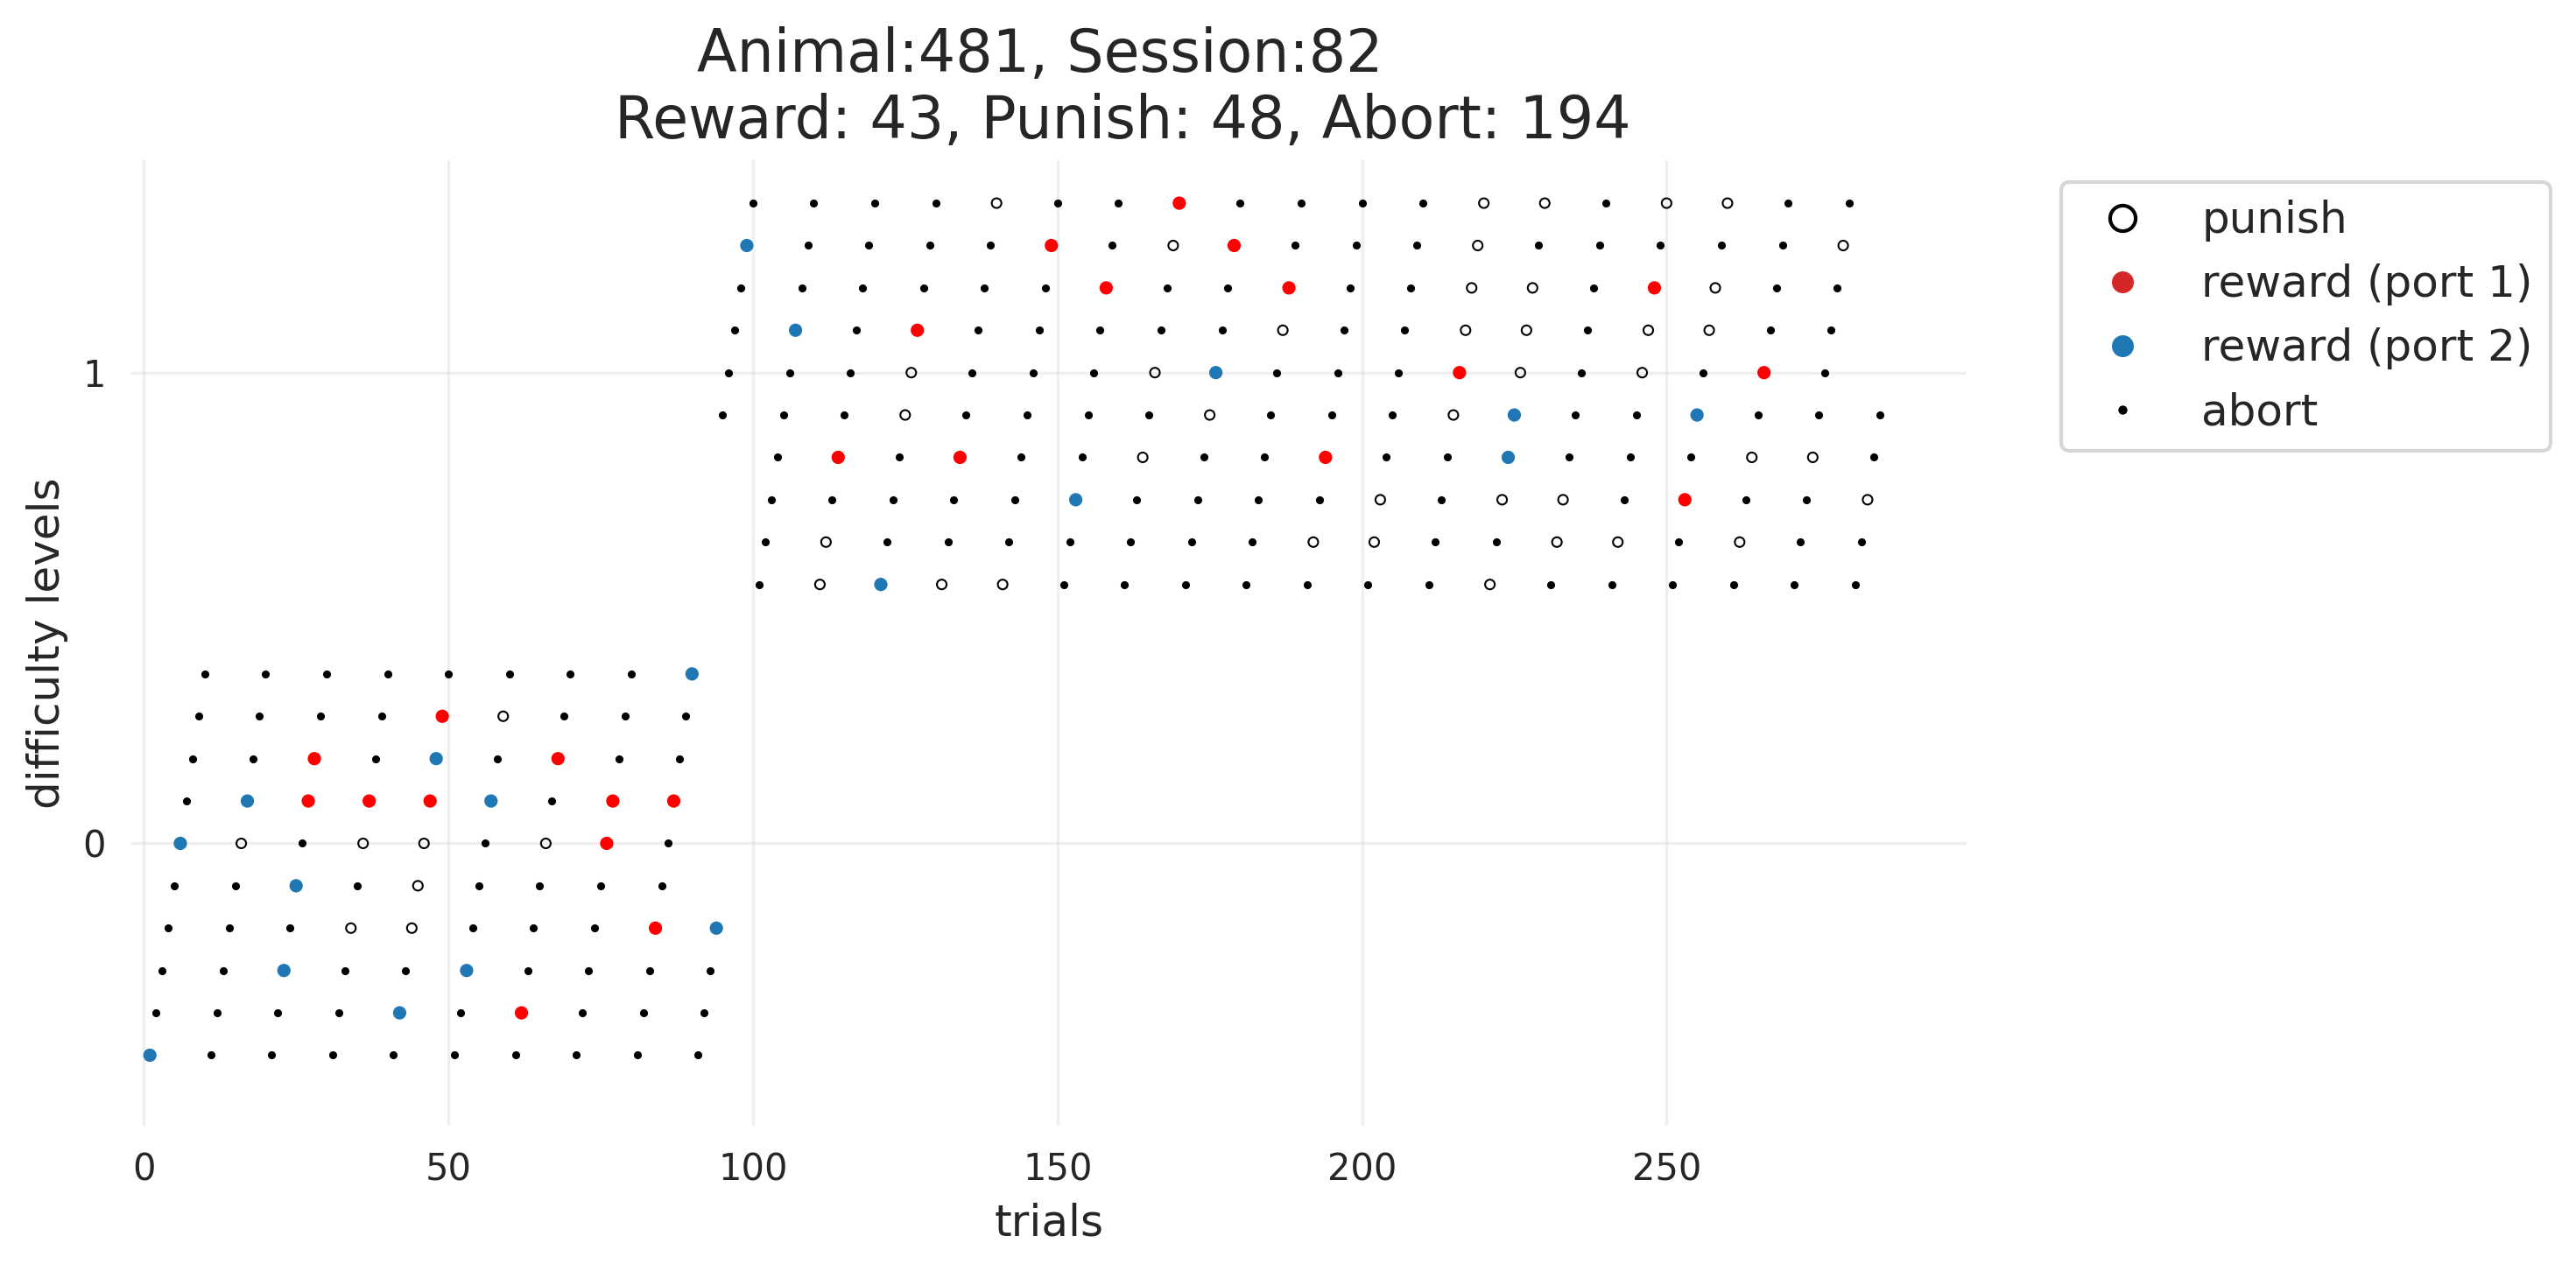

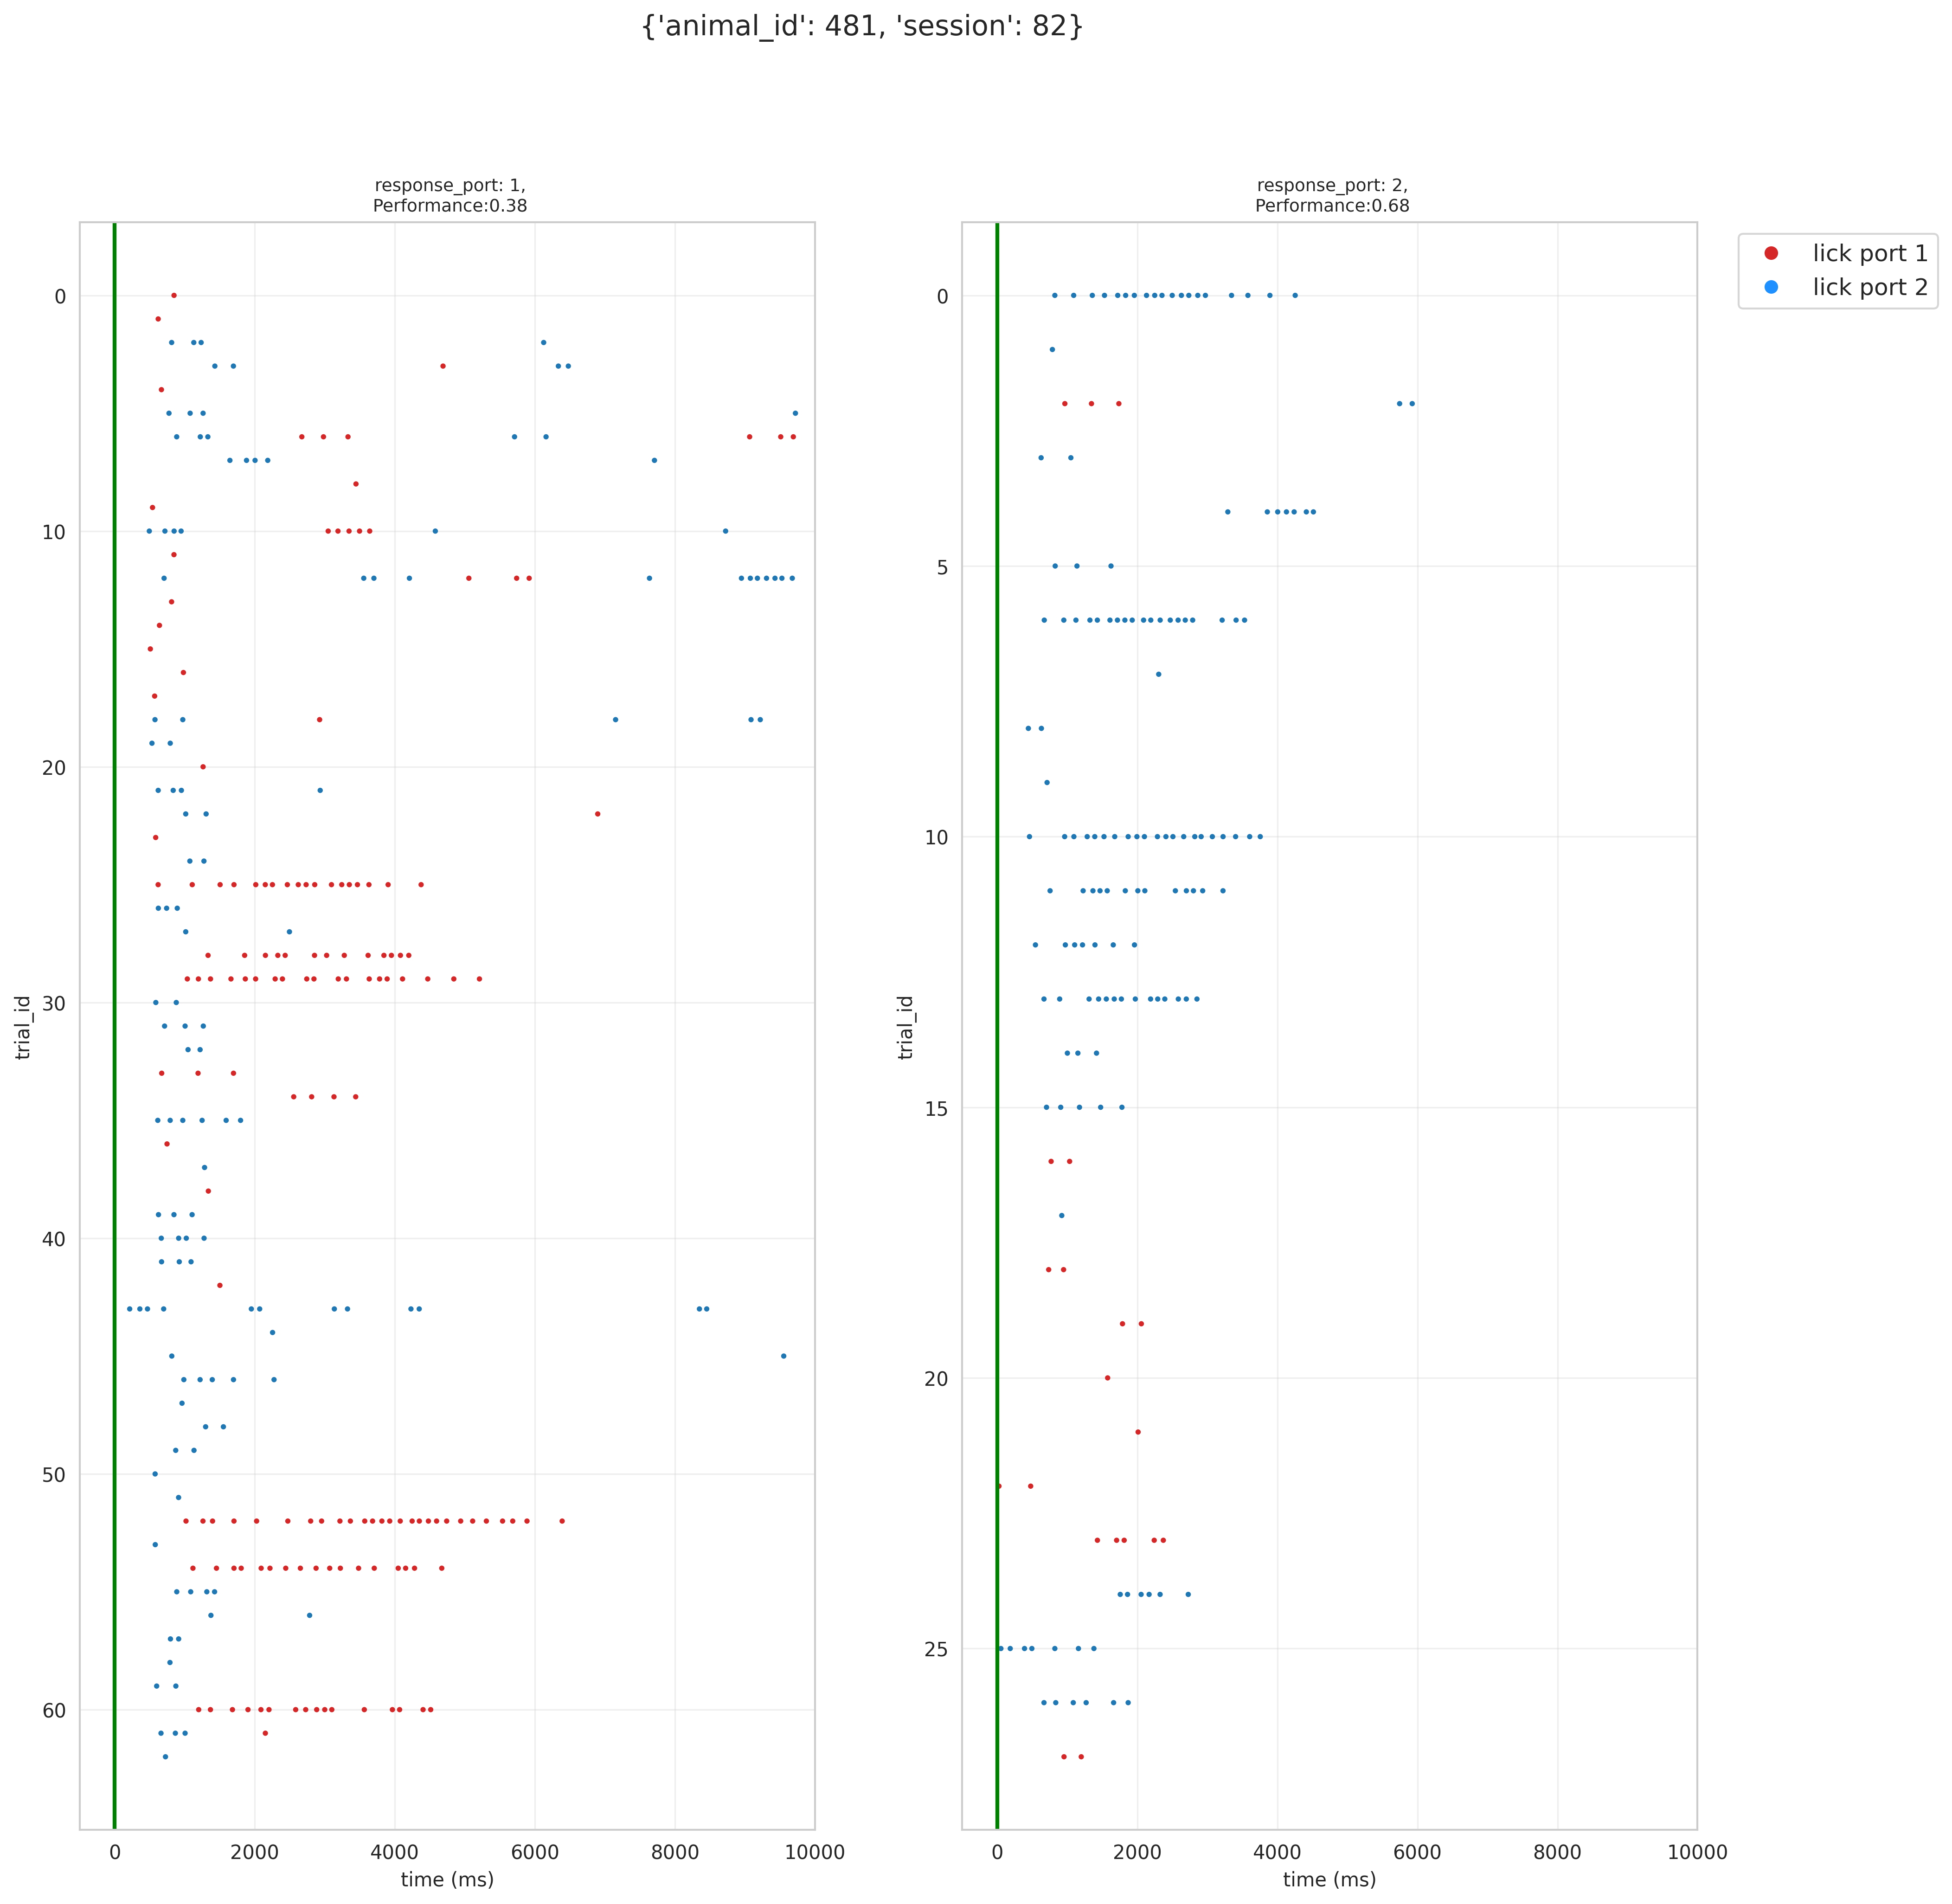

Total ON-OFF windows : 379
Windows with licks   : 1
Animal id: 482, session: 48
User name: bot
Setup: ef-rp8
Session start: 2026-10-01 10:00:02
Session duration: 32.40 minutes (1944.2 seconds)

Experiment:  MatchPort
Stimulus:  Panda
Behavior:  MultiPort

Task filename: object_discrimination_visual-dif0-1_pretraining_no_repeat.py
Git hash: b478cf9

Session performance: 0.6972477064220184
Number of trials: 363
difficulty 0: performance 0.95
difficulty 1: performance 0.67


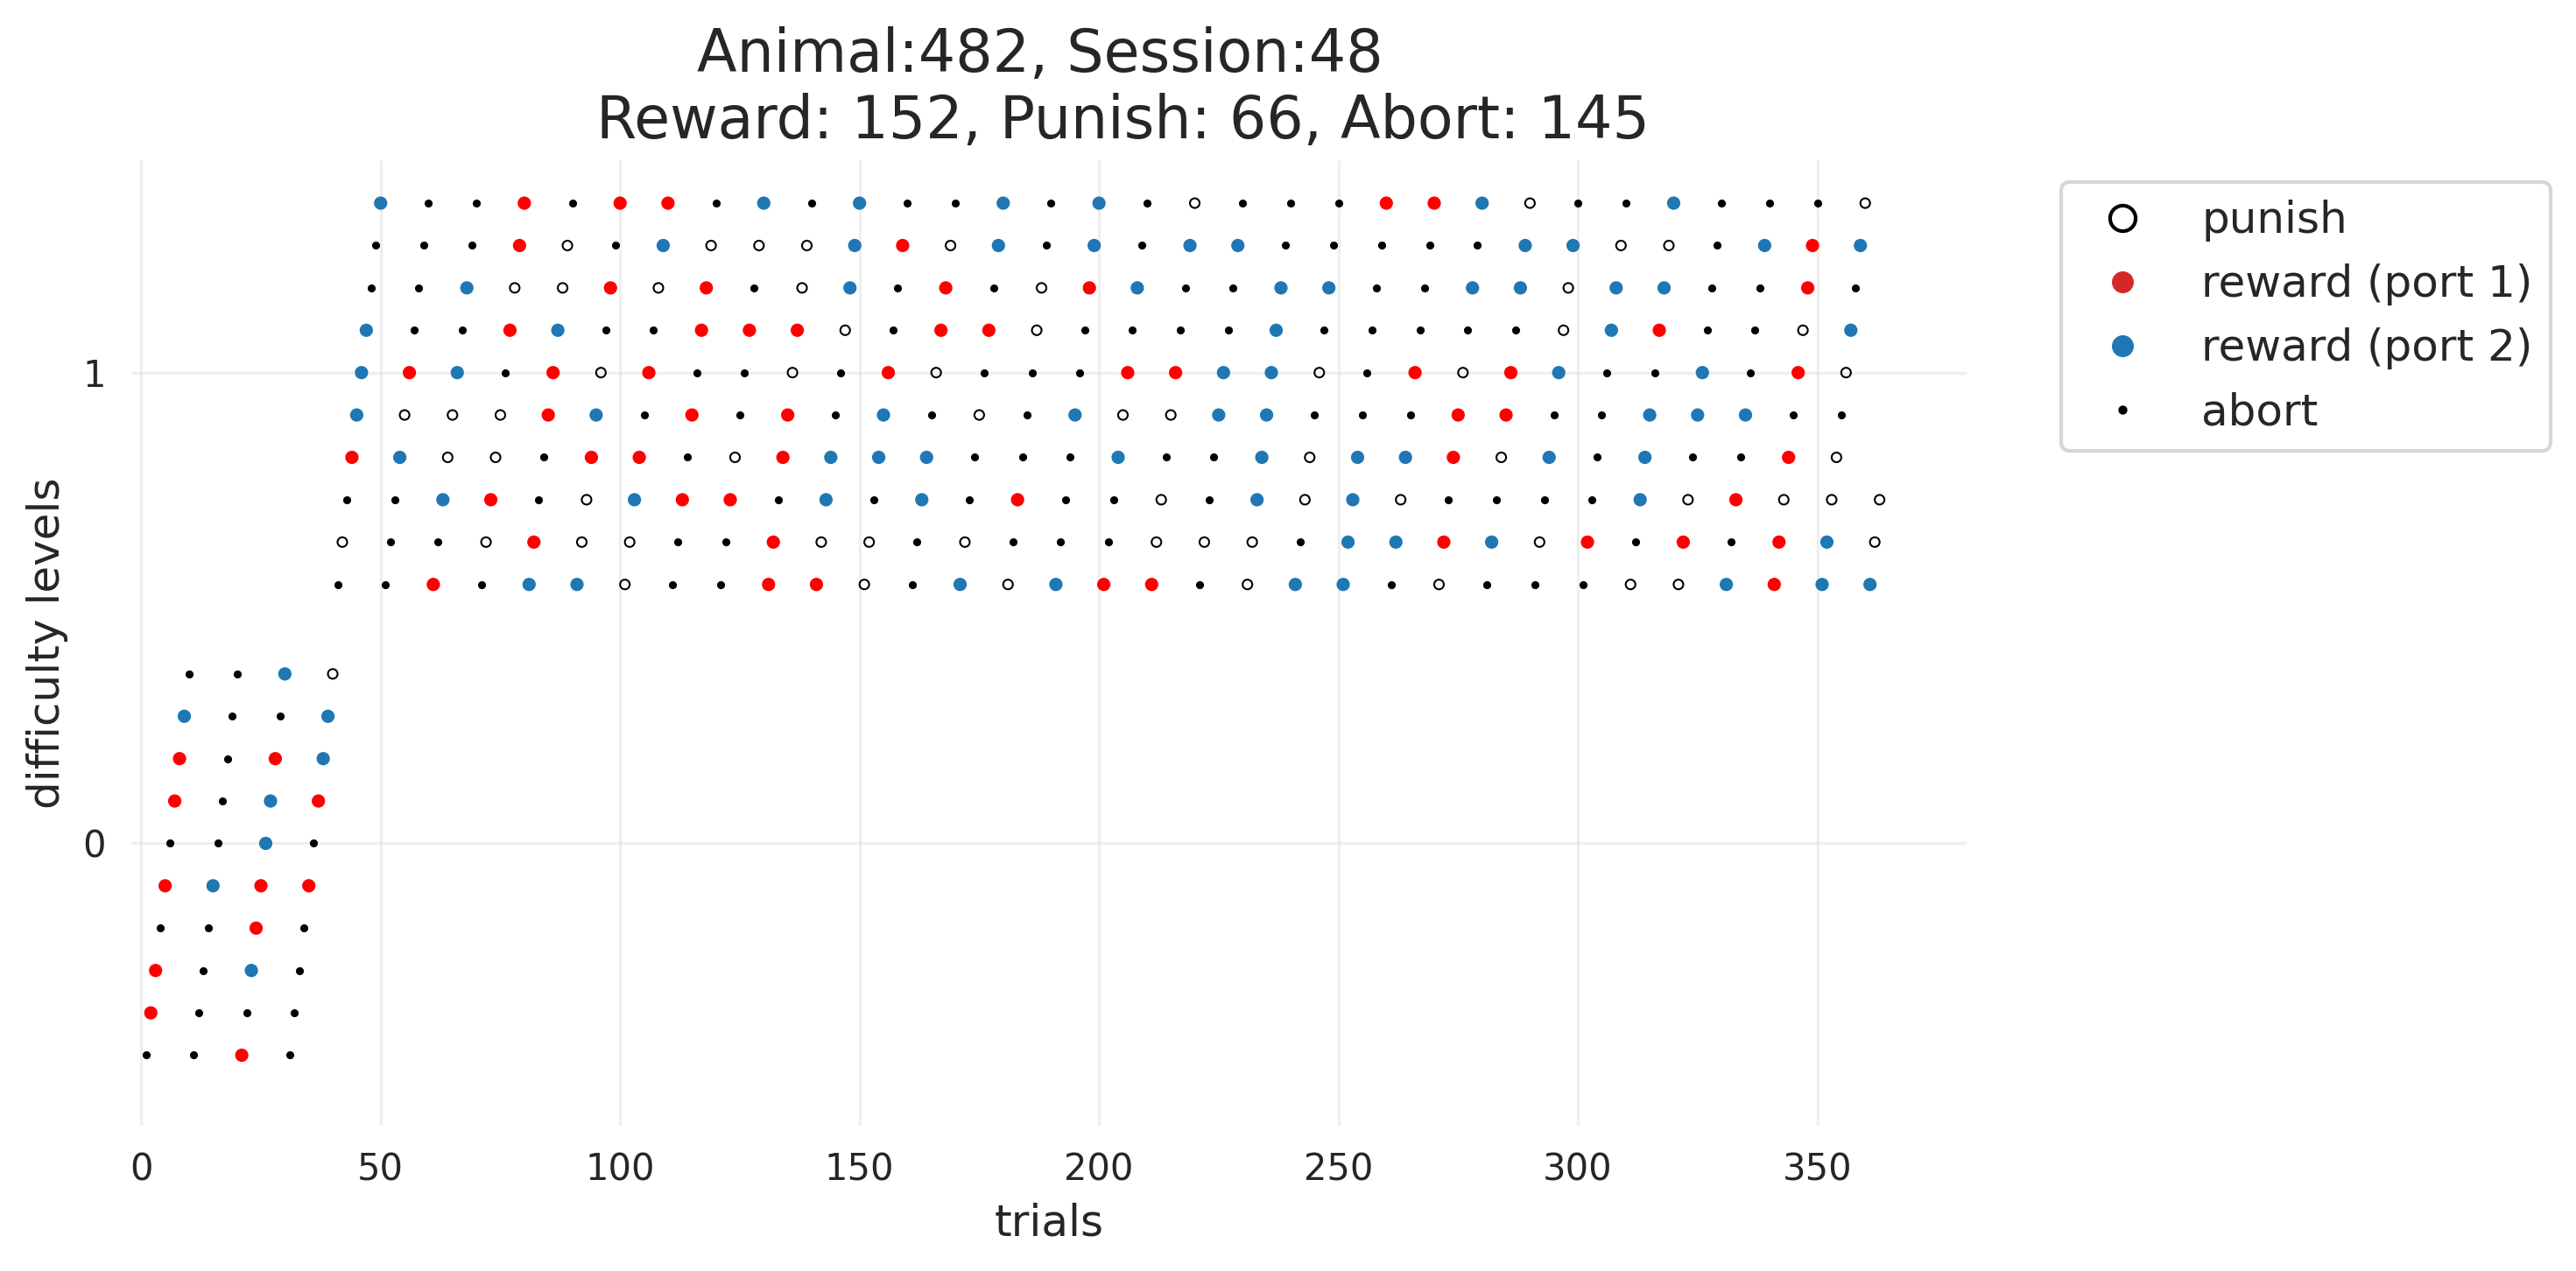

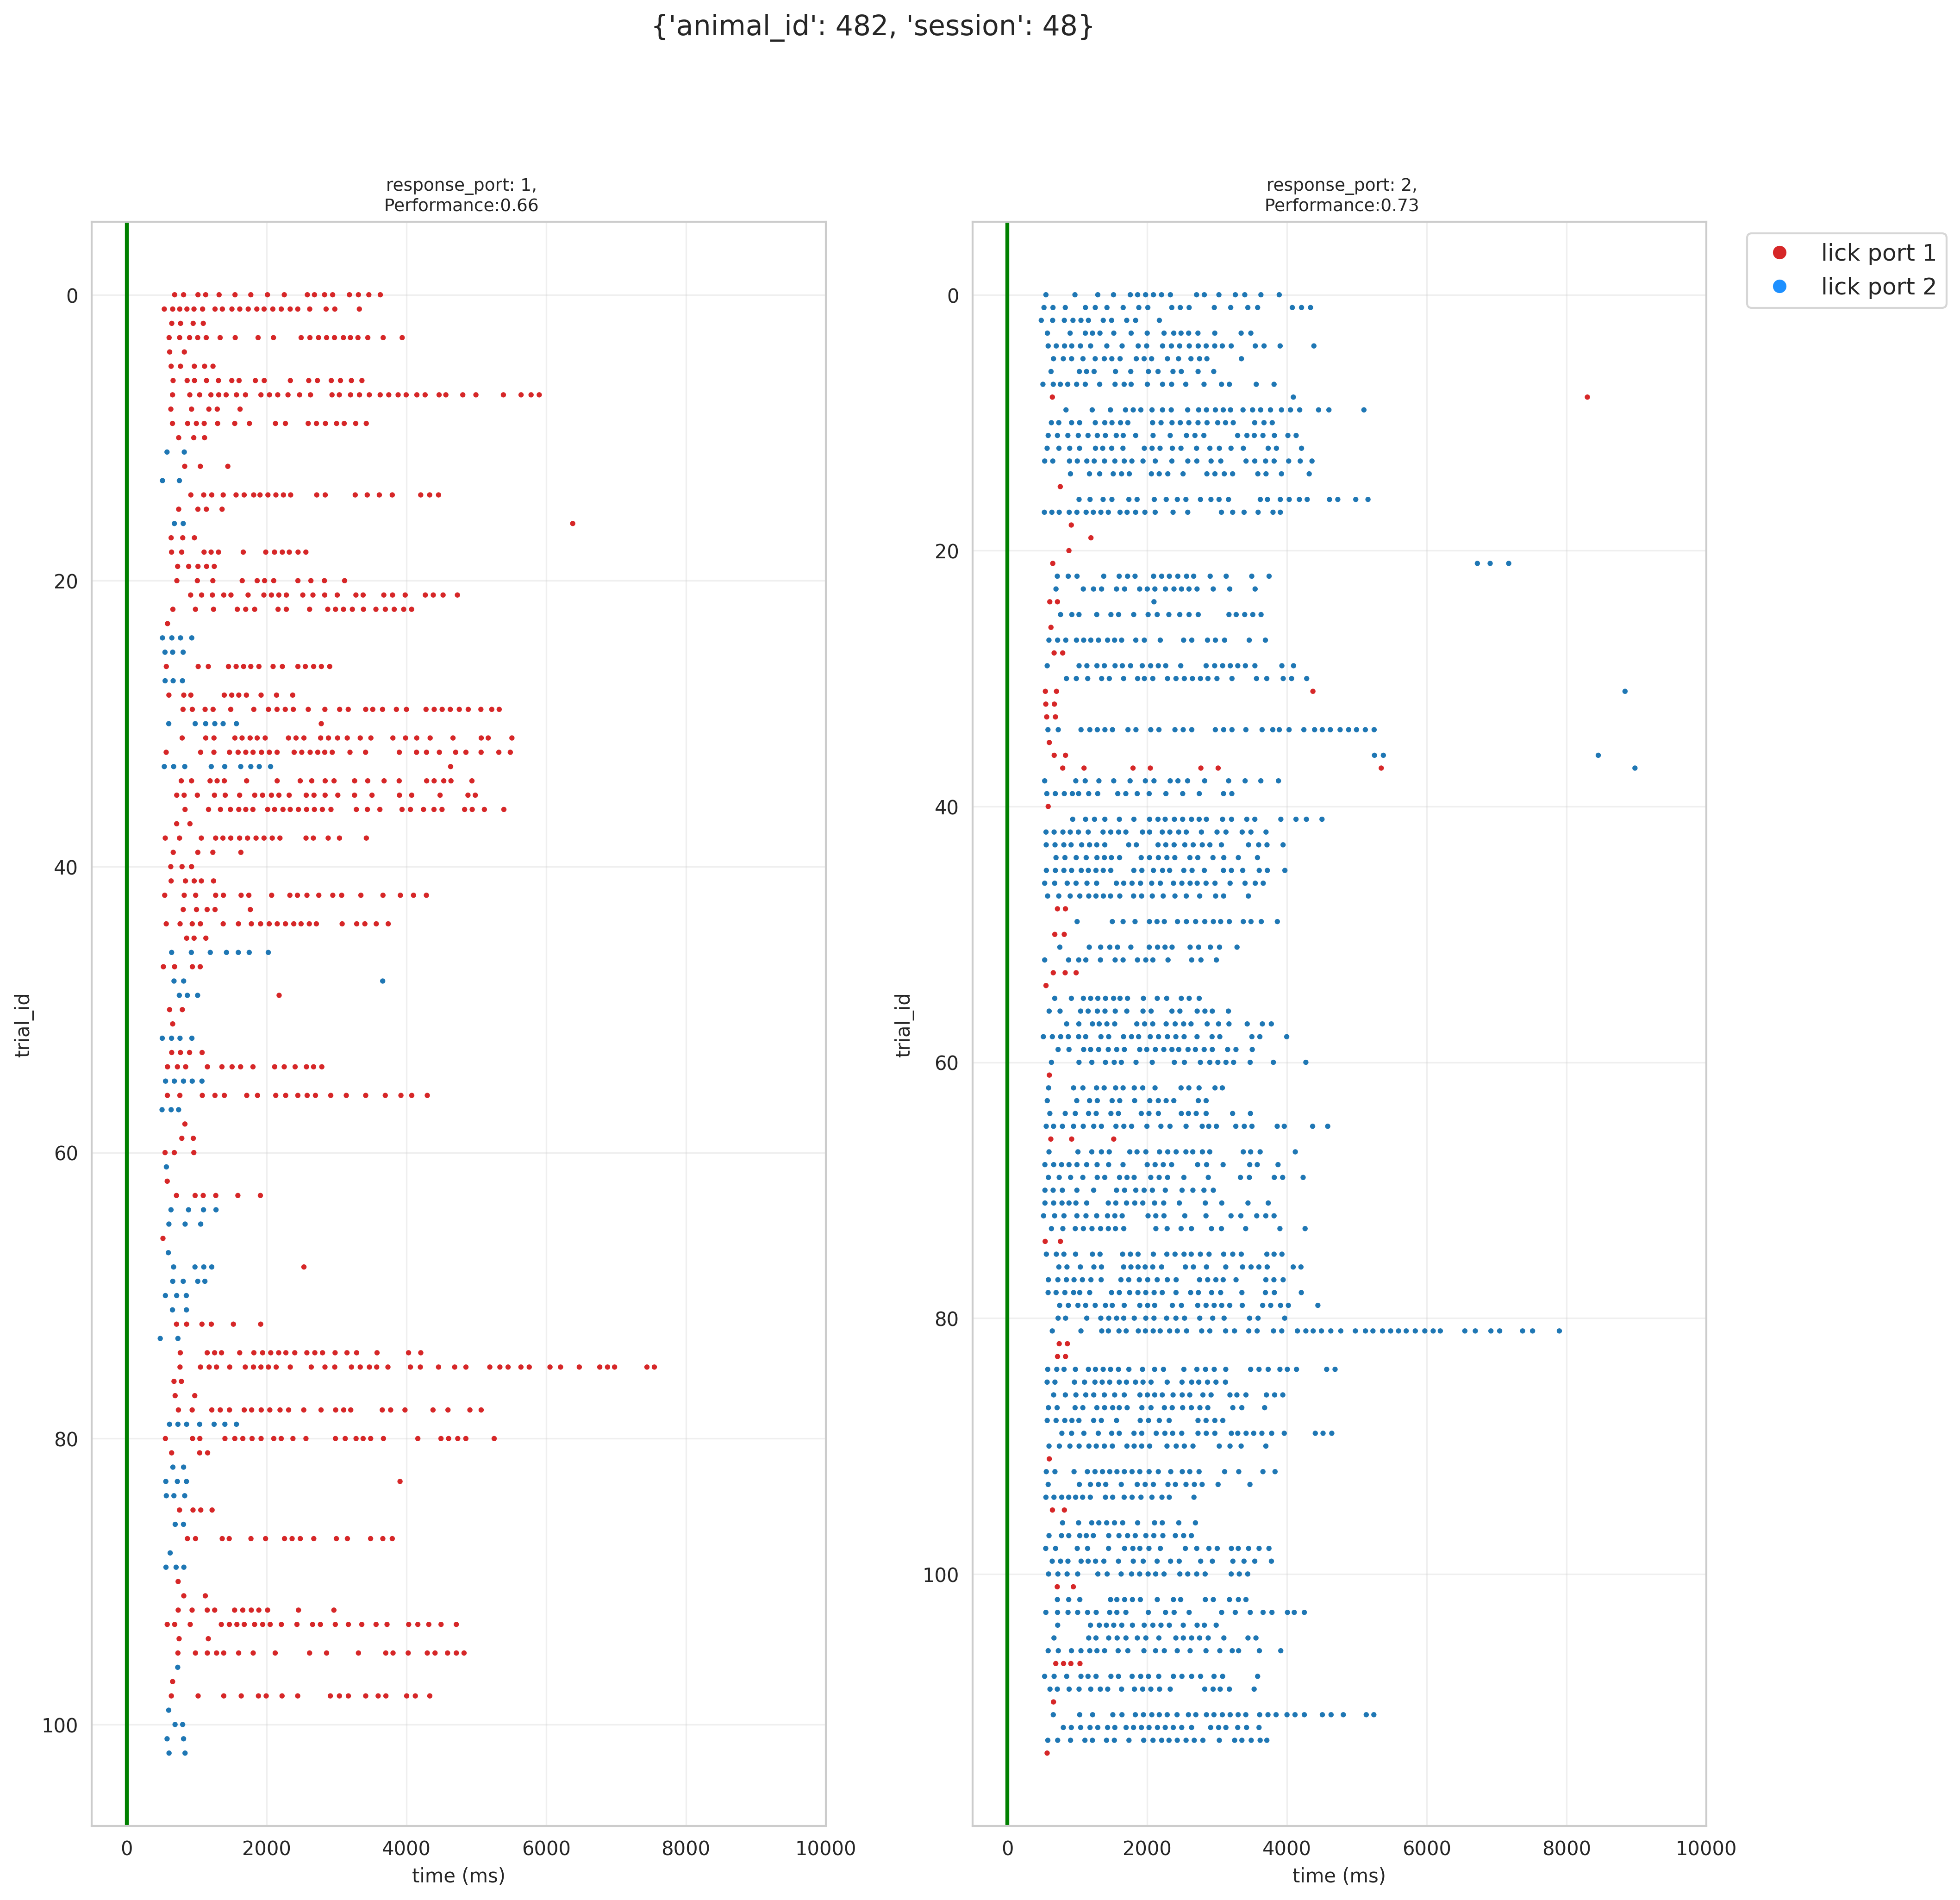

Total ON-OFF windows : 563
Windows with licks   : 1


In [215]:
from ethopy_analysis.plots import difficultyPlot

setup_list = [
    # 'ef-rp19',
    # 'ef-rp172',
    # 'ef-rp163',
    # 'ef-rp5',
    'ef-rp160',
    'ef-rp8',
]

custom_params = {"figsize": (10, 5),"marker_size":7,}

for setup in setup_list:
    animal_id, session = get_setup(setup)

    if animal_id is None or session is None:
        print(f"No data for {setup}, skipping...")
        continue
    
    session_summary(animal_id, session)
 
    # print('-------------------------------------------------------')
    difficultyPlot(animal_id, session, params=custom_params)
    # print('-------------------------------------------------------')
    LickPlot(animal_id, session, state_start='Trial')
    # print('-------------------------------------------------------')
    report = get_licks_during_proximity(animal_id, session)
    print(f"Total ON-OFF windows : {len(report)}")
    print(f"Windows with licks   : {report['has_lick'].sum()}")
    report[report["has_lick"]]
    print('=======================================================================================================================================')

## General plots
difficulty plot, lickplot, Proximity duration analysis, Proximity sensor analysis

In [216]:
# Get animal and session data from setup
# get_setup() retrieves animal_id and session for a given setup identifier
# Parameters: setup (str)
# Returns: Tuple[int, int] - (animal_id, session)

animal_id, session = get_setup("ef-rp160") #163, 3
# session_summary() prints comprehensive session information
# Parameters: animal_id (int), session (int)
# Displays: metadata, performance, trial count, experiment details
# animal_id = 299
# session = 799
session_summary(animal_id, session)

## get task_conf
# from ethopy_analysis.data.loaders import get_session_task
# filename, git_hash = get_session_task(animal_id, session, save_file=True)

# # Alternative: manually specify animal and get last session
# animal_id = x
# sessions = get_sessions(animal_id, min_trials=2)
# session = sessions['session'].iloc[-1]
# session_summary(animal_id, session)

Animal id: 481, session: 82
User name: bot
Setup: ef-rp160
Session start: 2026-10-01 10:00:01
Session duration: 32.62 minutes (1957.2 seconds)

Experiment:  MatchPort
Stimulus:  Panda
Behavior:  MultiPort

Task filename: object_discrimination_visual-dif0-1_pretraining.py
Git hash: b478cf9

Session performance: 0.4782608695652174
Number of trials: 289


difficulty 0: performance 0.73
difficulty 1: performance 0.35


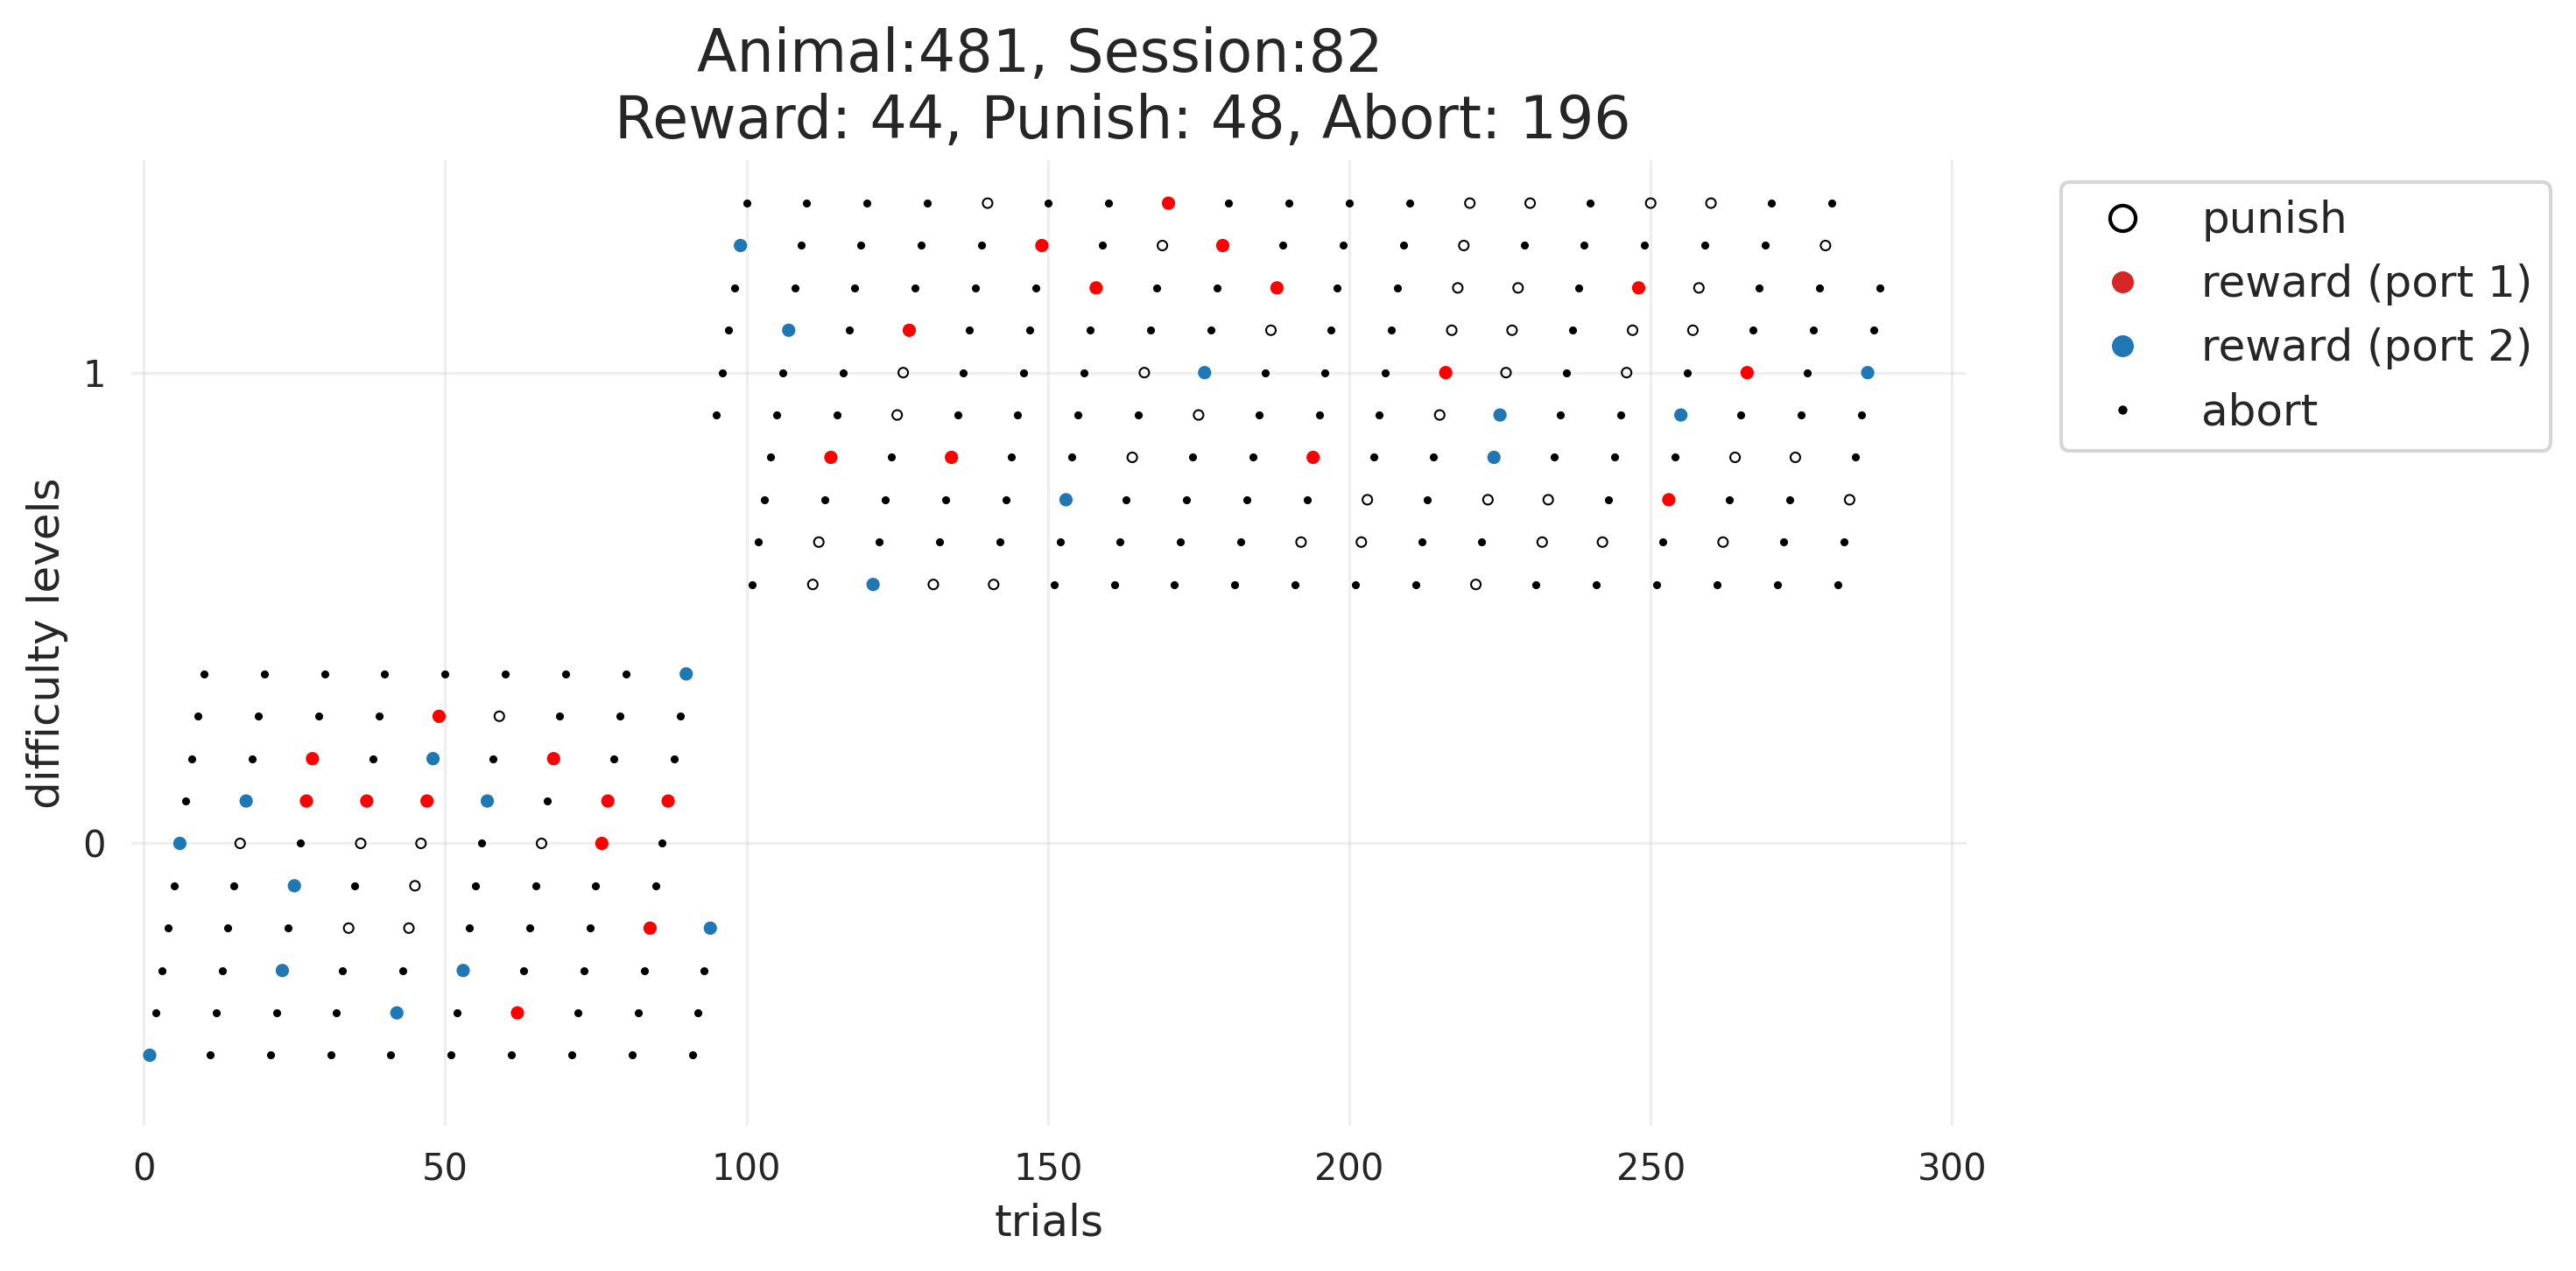

In [217]:
from ethopy_analysis.plots import difficultyPlot
# Plotz trial outcomes across difficulty levels
# difficultyPlot() creates comprehensive visualization of trial outcomes over time
# Parameters: animal_id (int), session (int), save_path (str)
# Shows: reward/punish/abort trials color-coded by response port and difficulty
custom_params = {
    "figsize": (10, 5),
    "marker_size":7,
}
difficultyPlot(animal_id, session, params=custom_params)

## lickplot

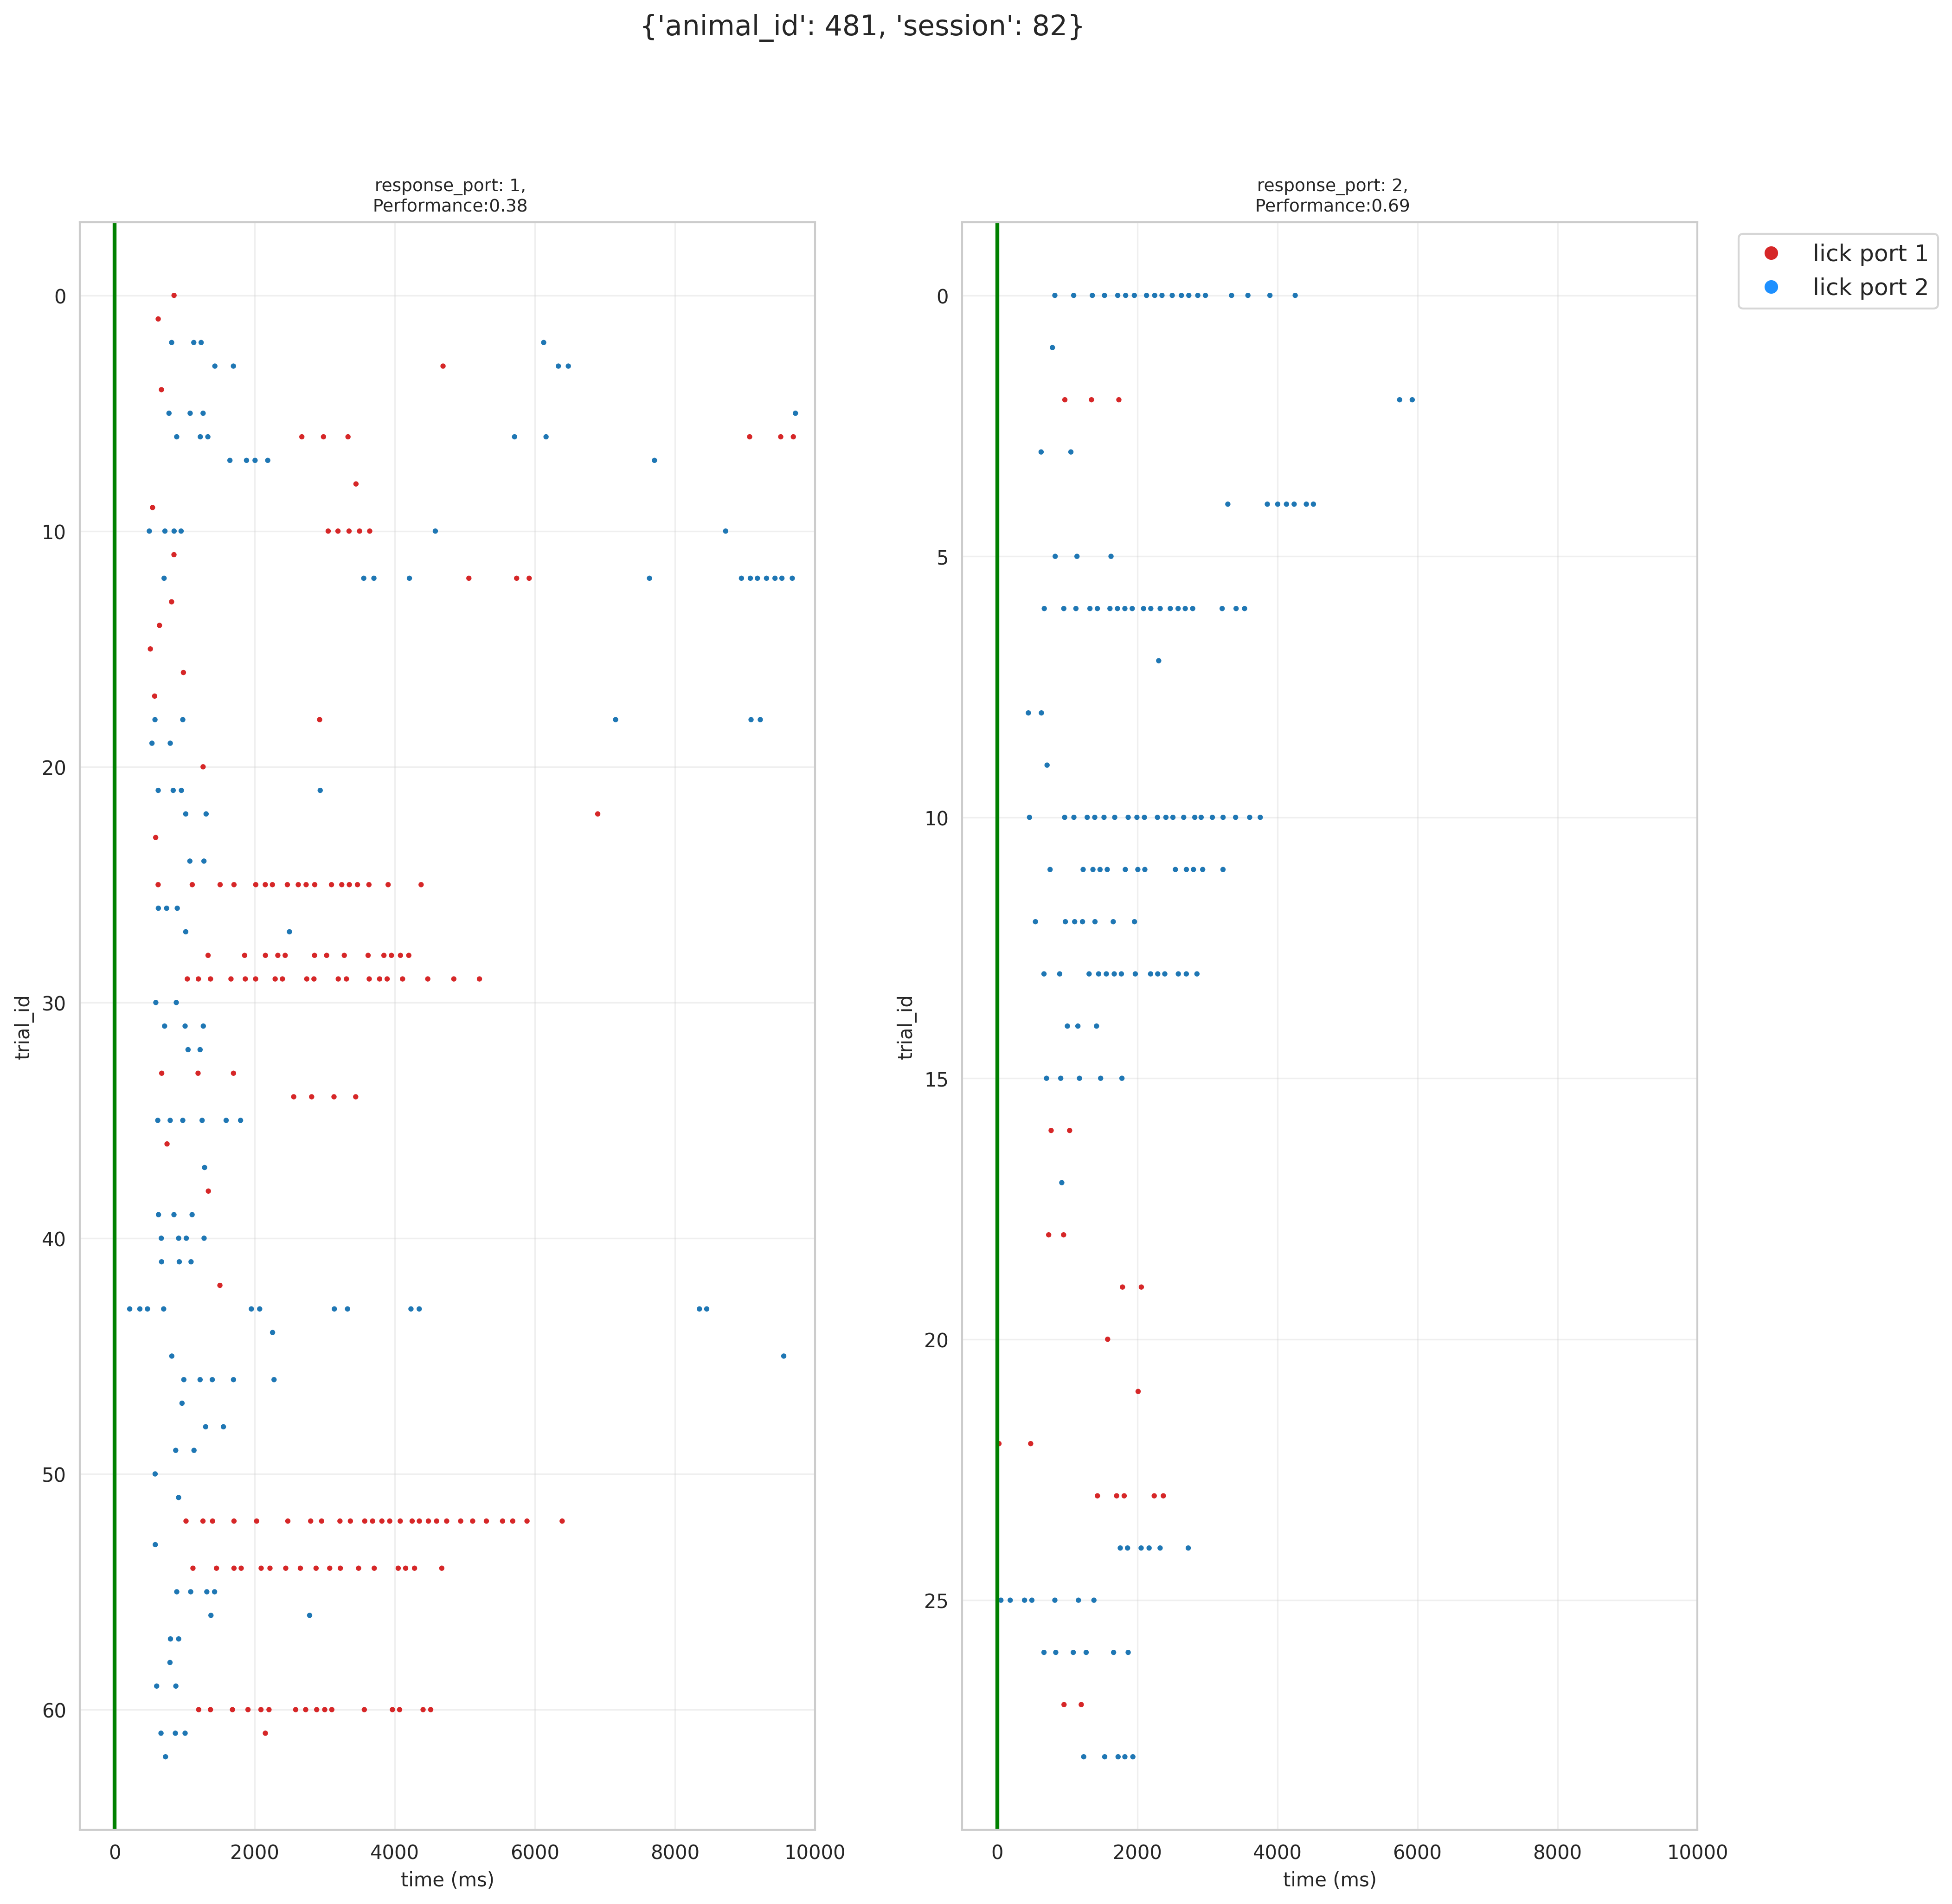

port: 2
 mean licks: 7.75
 trials count: 16
port: 1
 mean licks: 13.625
 trials count: 8


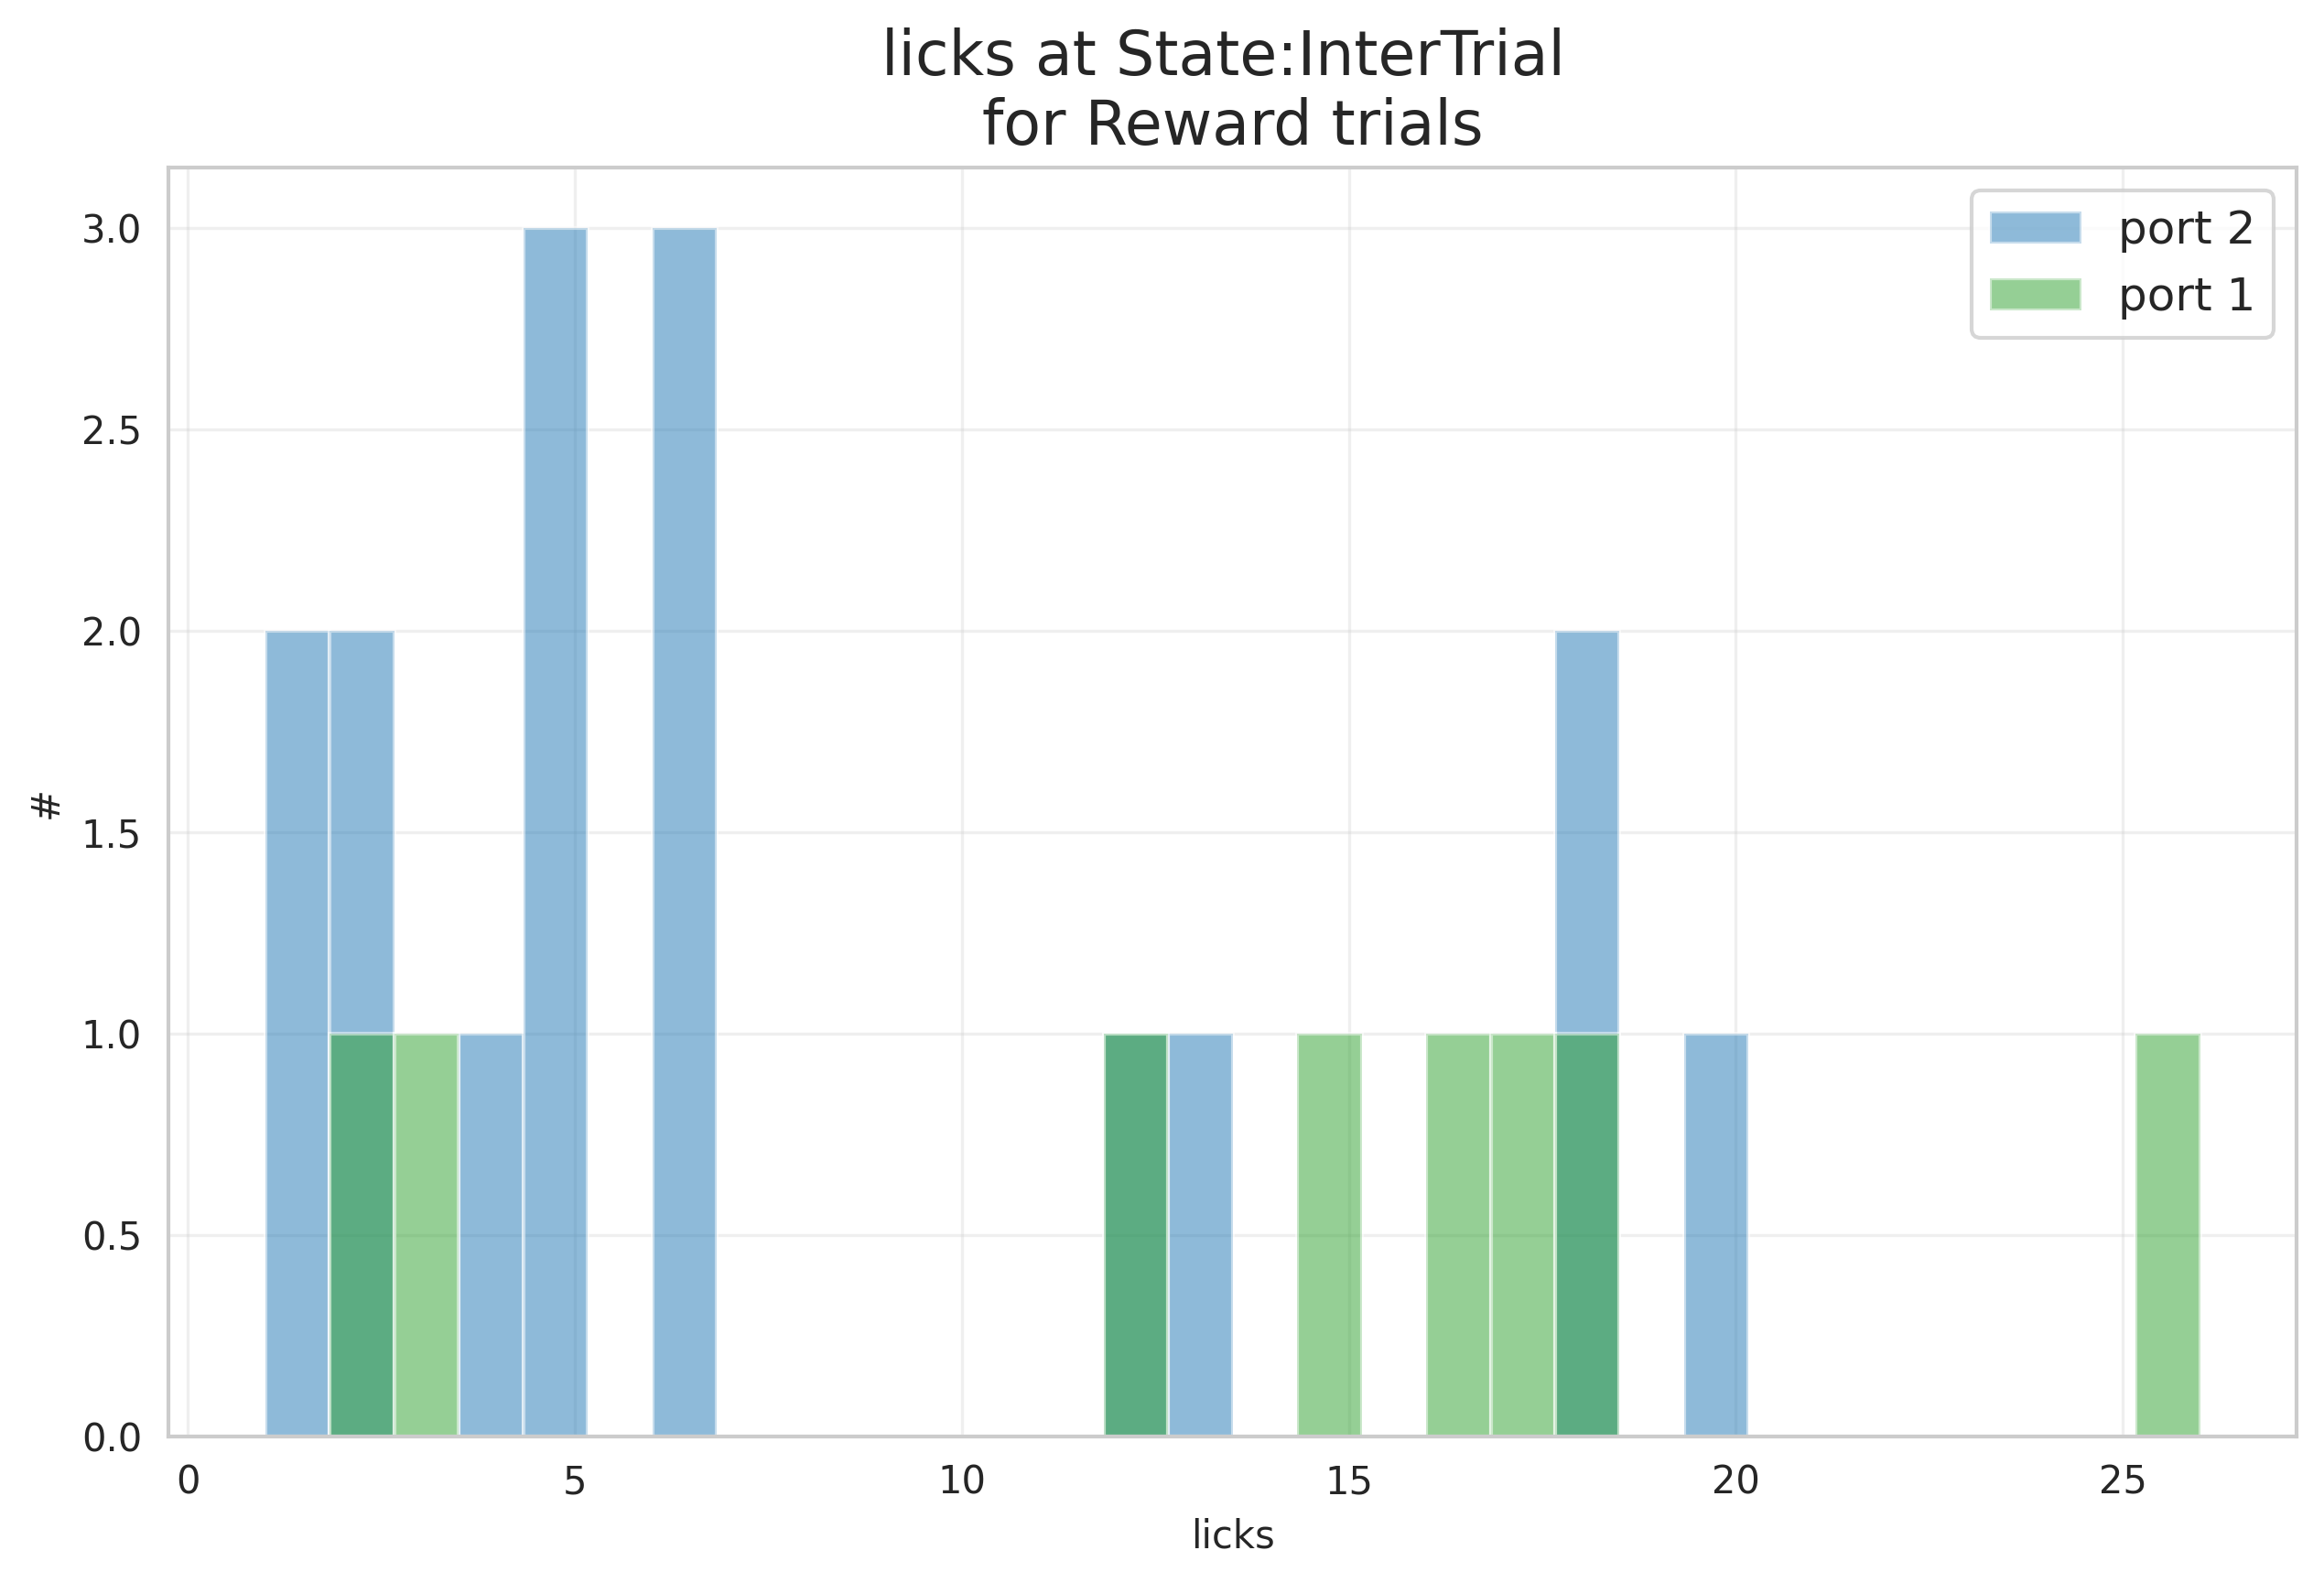

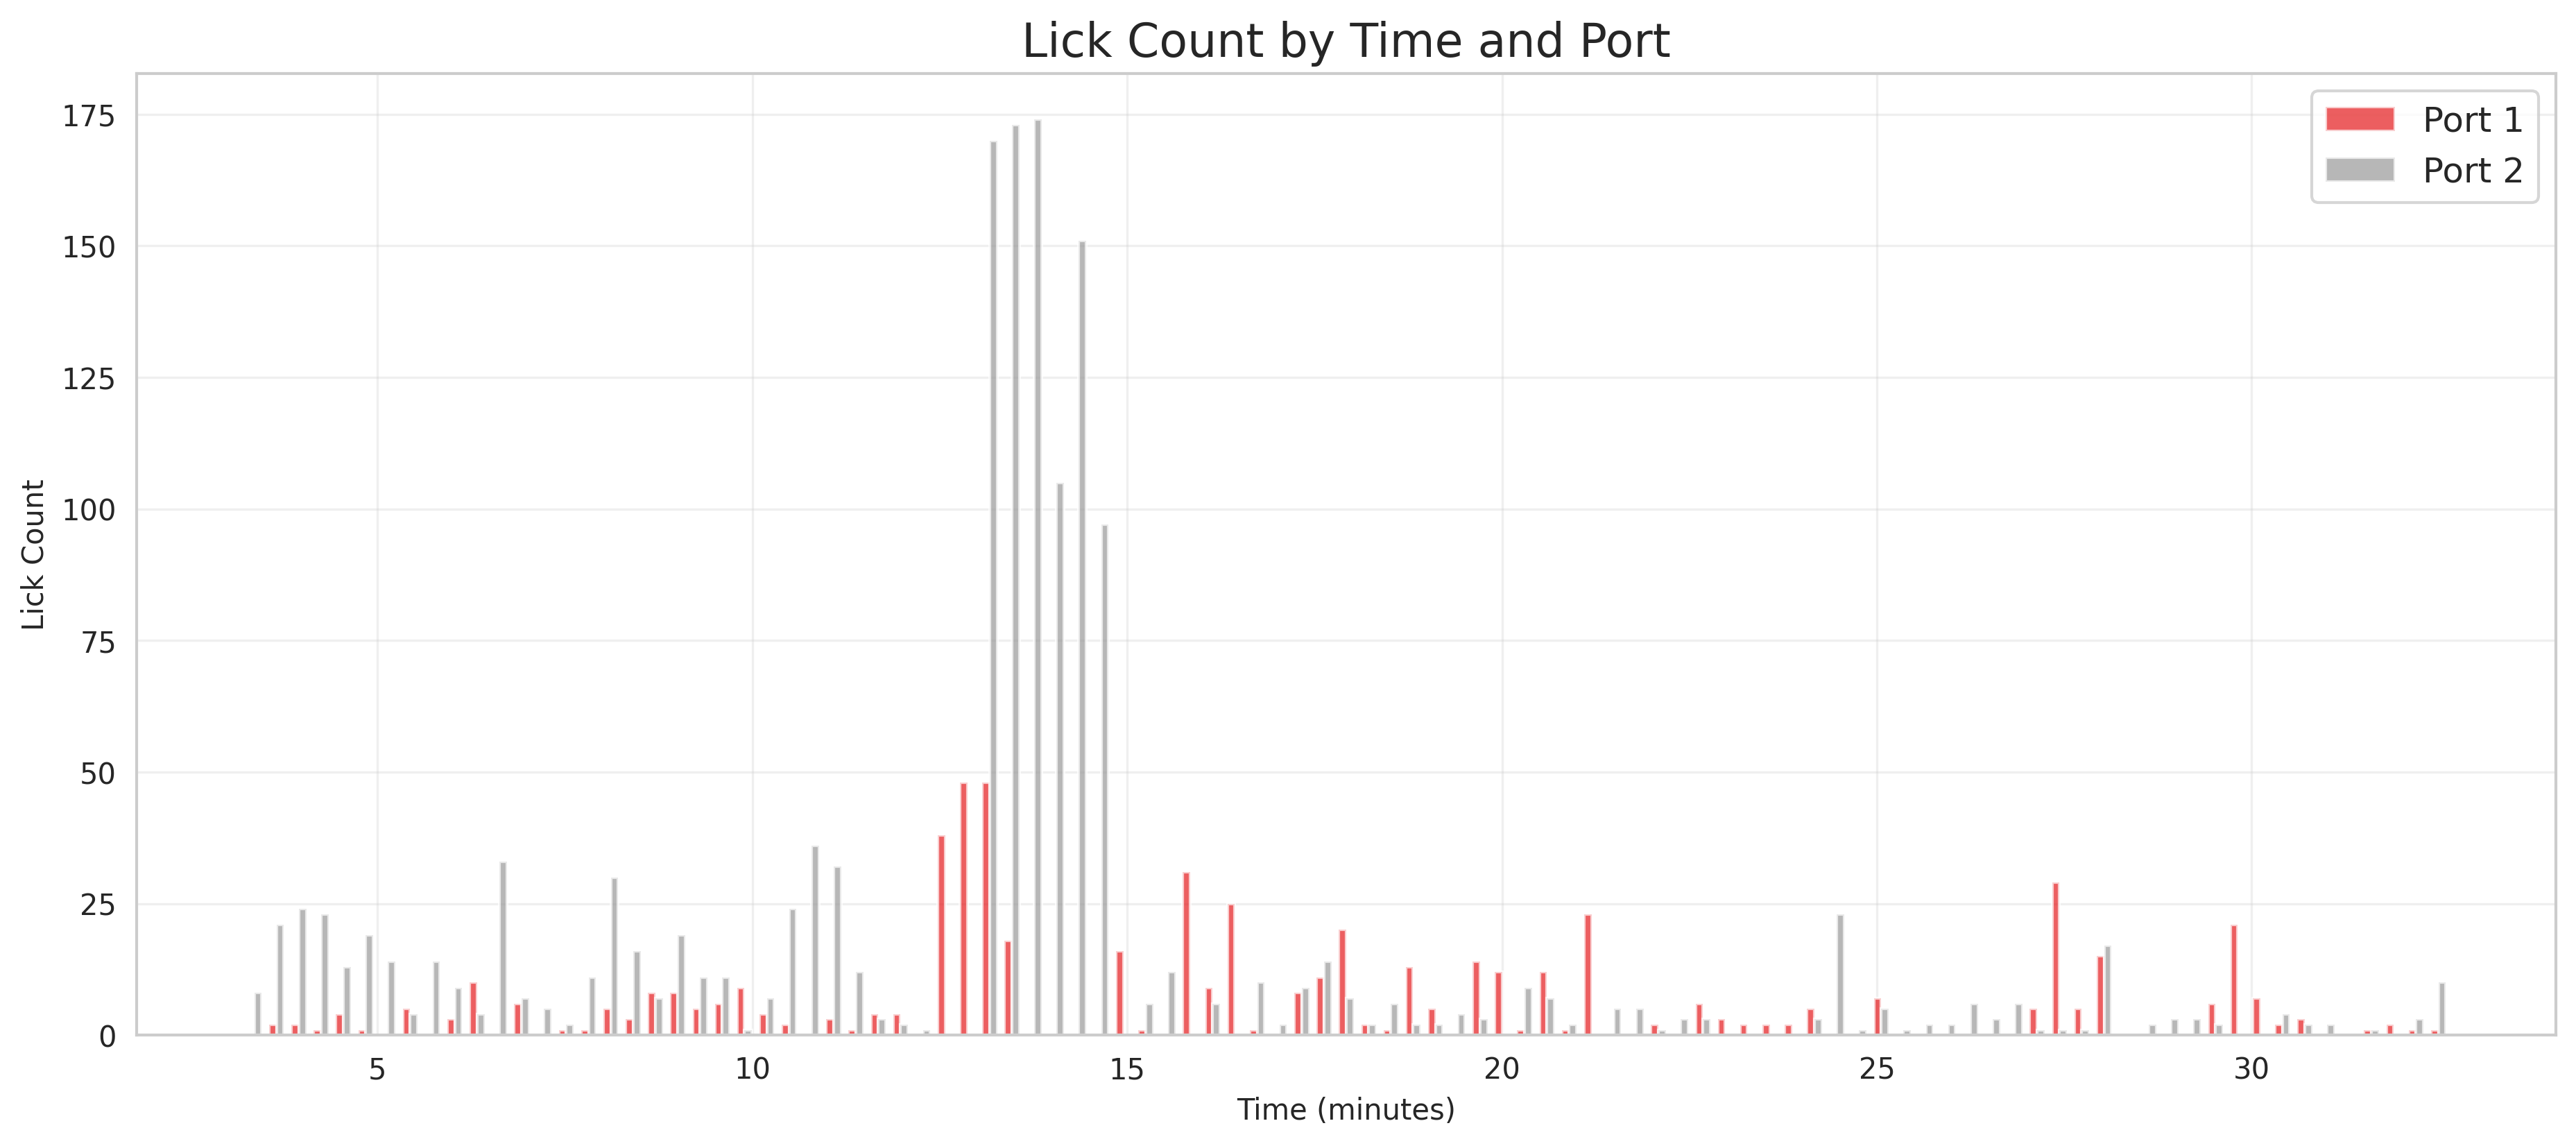

############### last date: 2026-10-01, amount: 264.0 ###############


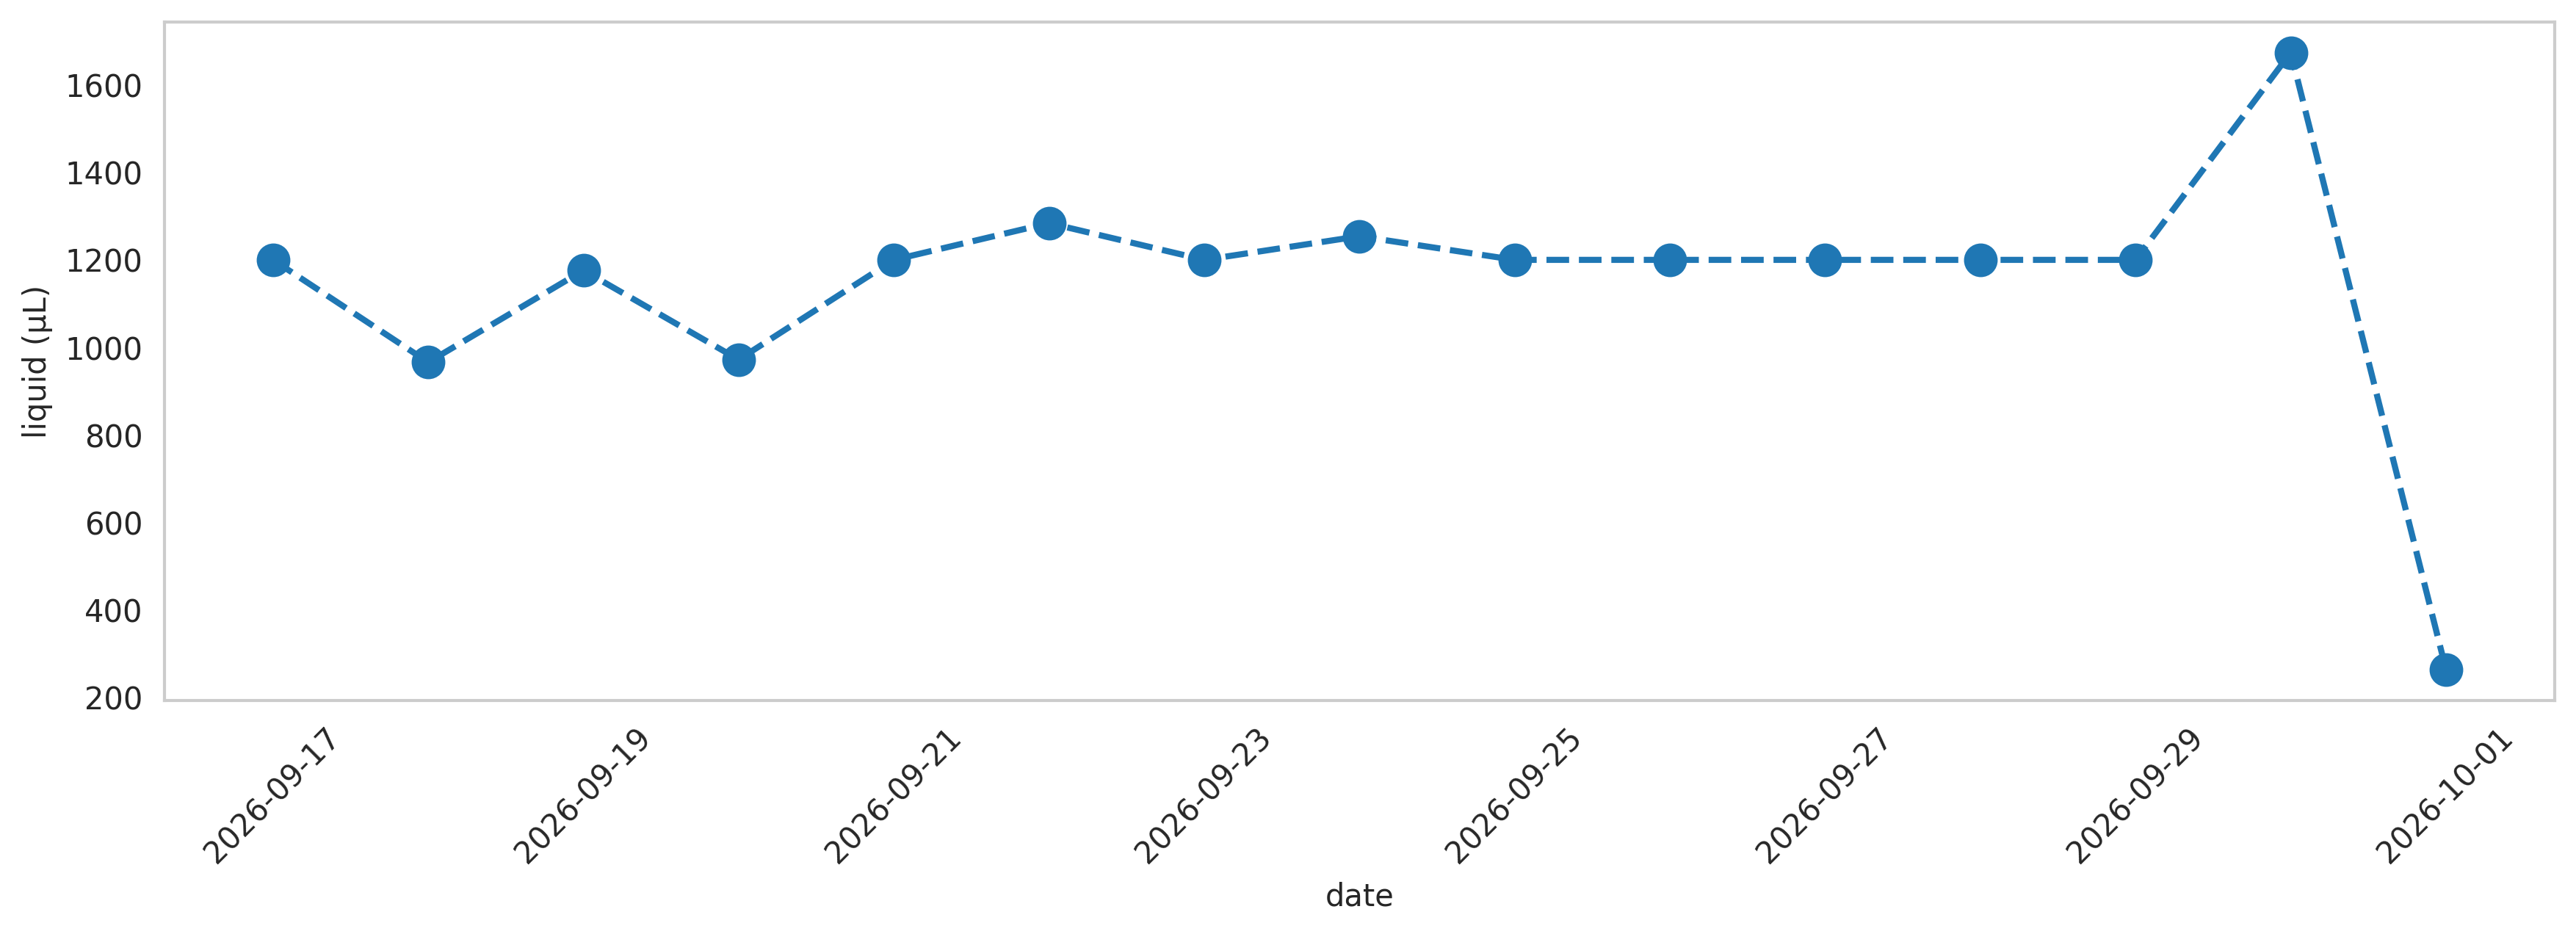

In [218]:
# Licking behavior analysis
# LickPlot() generates lick plots across conditions
# Parameters: 
# animal_id (int), session (int), 
# conds_split (List[str]): a list of conditions to seperate the licks
# state_start (str): the state to start plotting from, defaults to 'Trial'
# stim_table (datajoint.query): the table containing stimulus information, defaults to stimulus.StimCondition()
# color_rew_pun (bool): whether to color by reward/punish
# difficulty (int): the difficulty level of the task
# period (str): the time period to analyze Optional, in MatchToSample period should be 'Cue'
# save_path (str): the path to save the plot
LickPlot(animal_id, session, state_start='Trial')
# LickPlot(animal_id, session, state_start='Trial', difficulty=0)
# LickPlot(animal_id, session, state_start='Trial', difficulty=1)


# plot_licks_state() analyzes licks during specific states
# Parameters: animal_id (int), session (int), check_state (str), state_select (str), bins (int)
plot_licks_state(animal_id, session, bins=30)

# plot_licks_time() shows lick patterns over time by port
# Parameters: animal_id (int), session (int), bins (int), save_path (str)
plot_licks_time(animal_id, session, bins=100)

# liquidsPlot() shows daily liquid reward consumption
# Parameters: animal_id (int), days (int), save_path (str)
liquidsPlot(animal_id, days=15)

## proximity sensor plot

/home/jupyter-anastasios/.local/lib/python3.10/site-packages/ethopy_analysis/plots/session.py:818: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ready_times_state = states_check.groupby("trial_idx").apply(
/home/jupyter-anastasios/.local/lib/python3.10/site-packages/ethopy_analysis/plots/session.py:818: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ready_times_state = states_check.groupby("trial_idx").apply(


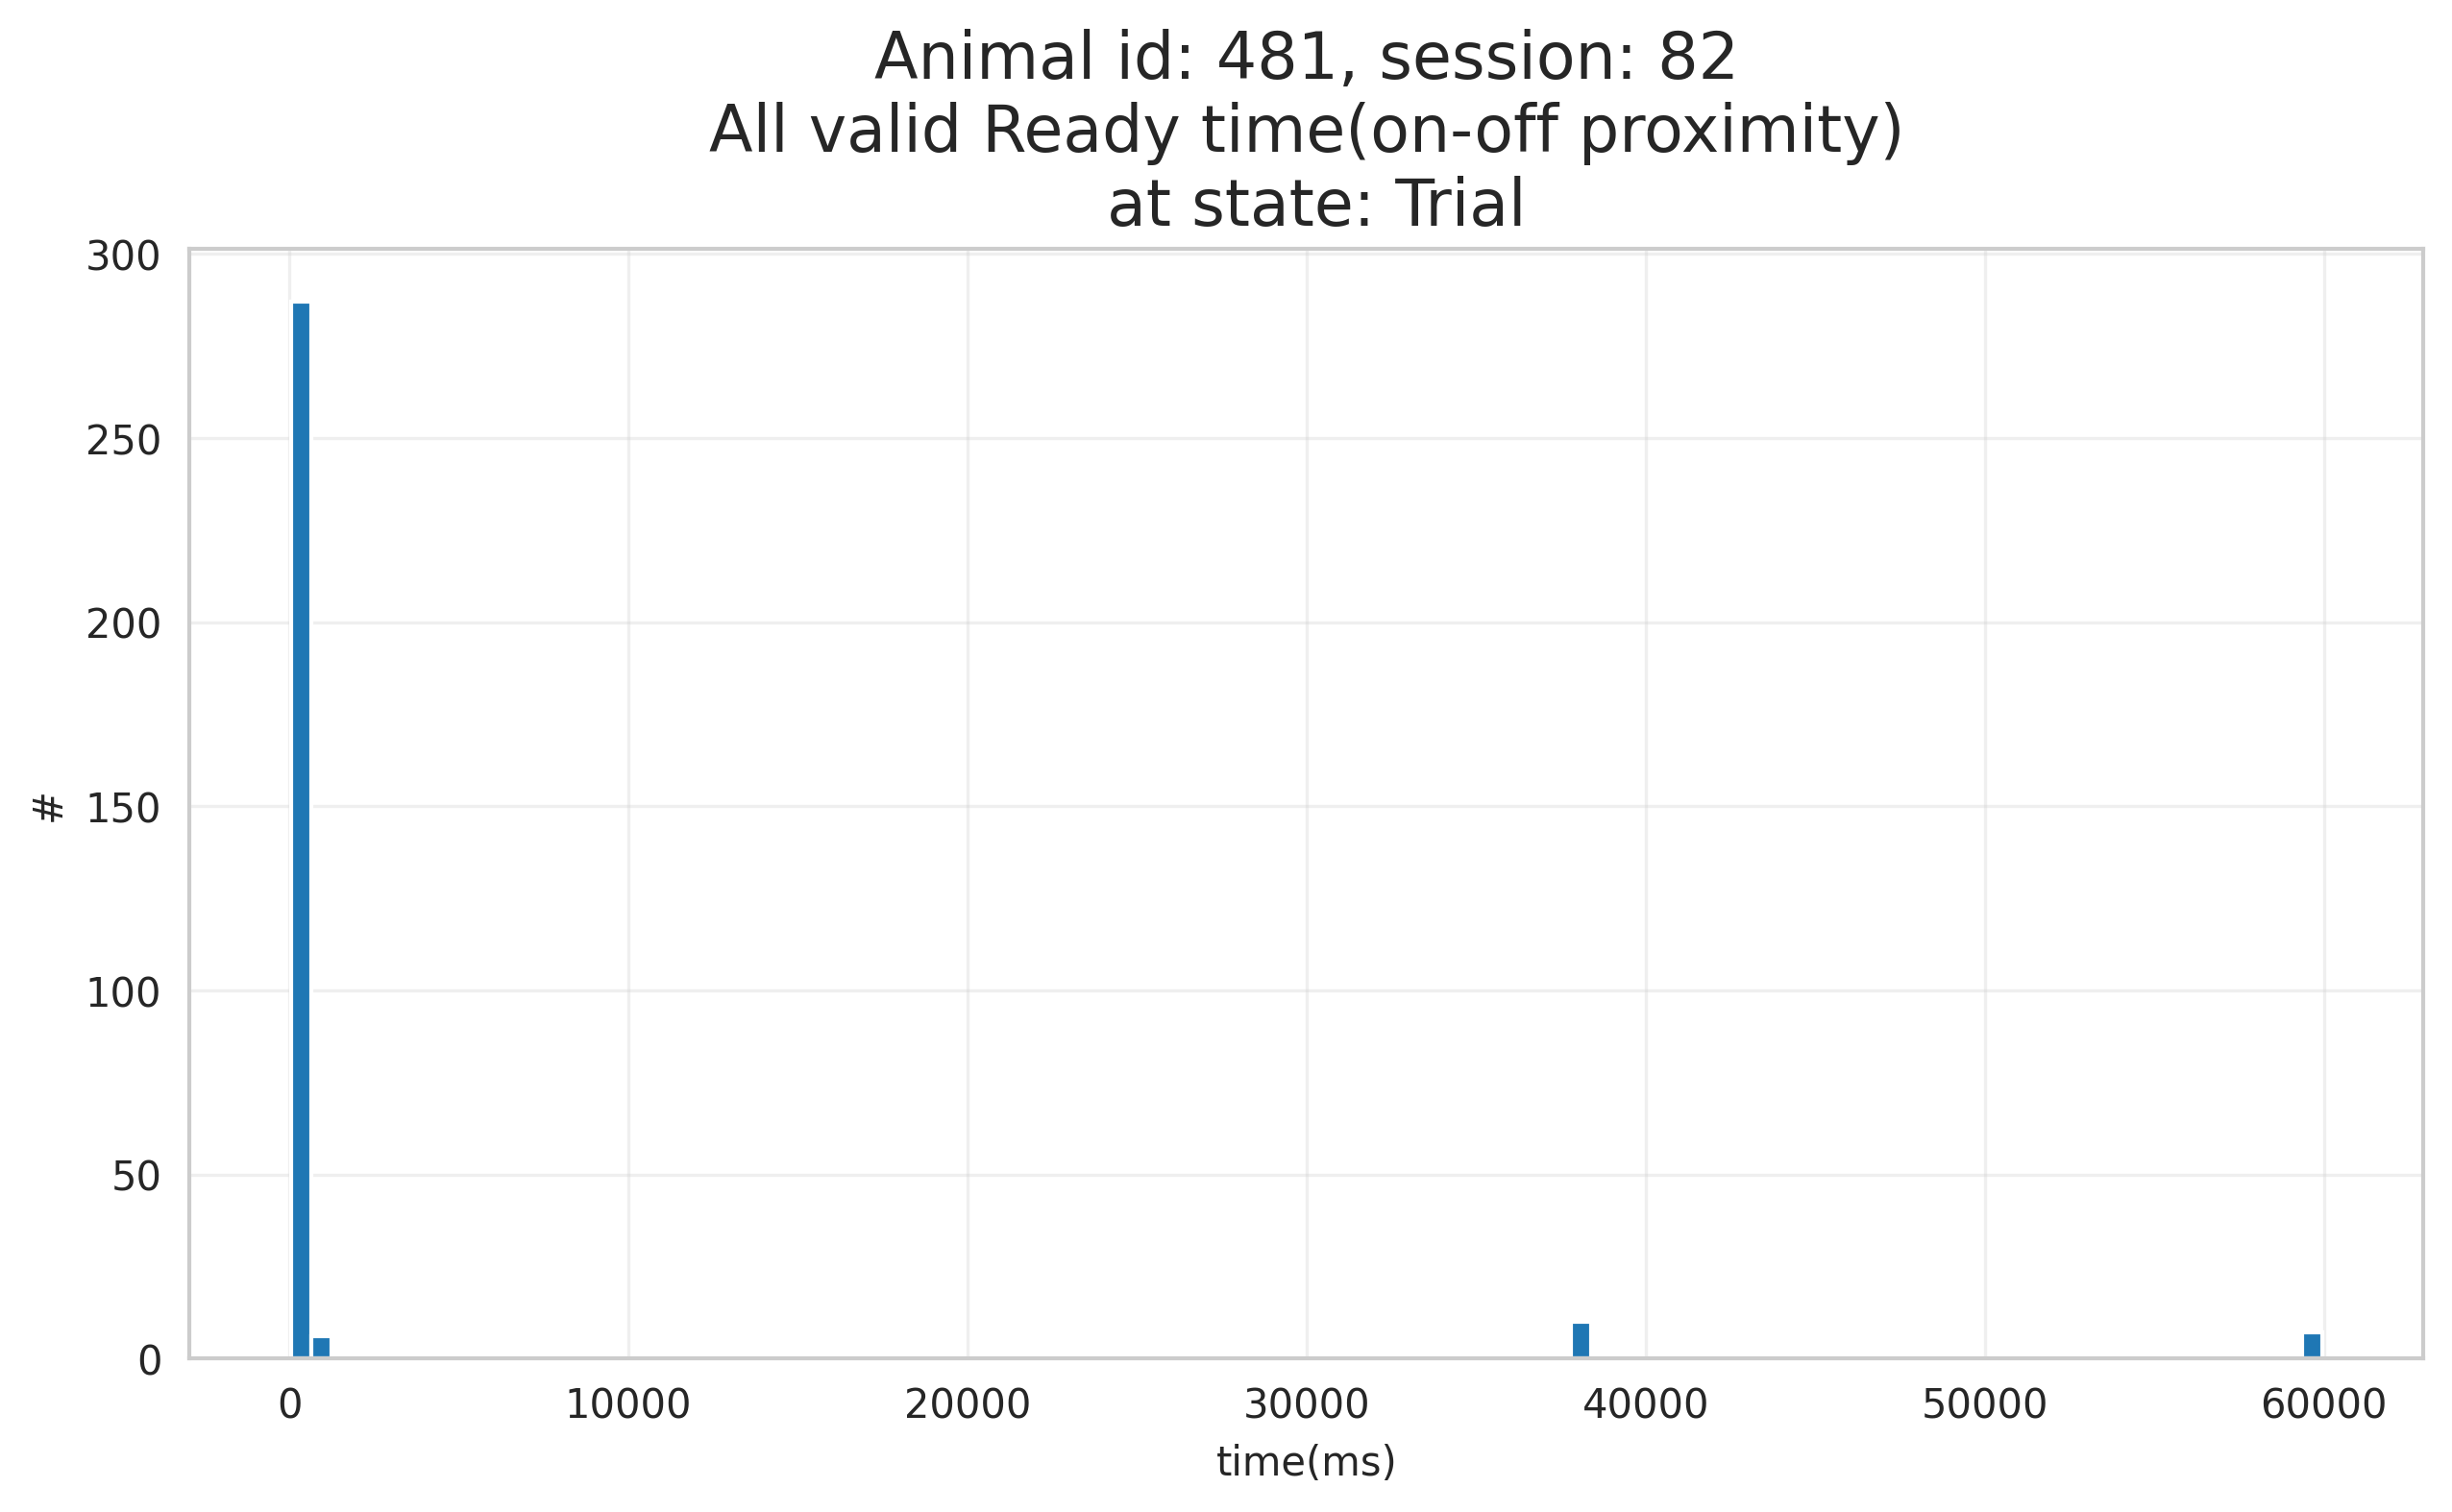

In [223]:
# Proximity sensor analysis
# valid_ready_state() calculates valid ready times for a state
# Parameters: animal_id (int), session (int), state (str)
# Returns: Series with ready times grouped by trial
ready_times_state = valid_ready_state(animal_id, session, state='Trial')

# plot_valid_proximity_state() plots histogram of valid proximity durations
# Parameters: animal_id (int), session (int), state (str), save_path (str)
plot_valid_proximity_state(animal_id, session, state="Trial")

# # Analyze last ready time per trial
# last_on_off = [readys[-1] for readys in ready_times_state if len(readys) > 0]

# plt.figure(figsize=(10, 5))
# plt.hist(last_on_off, bins=100)
# plt.title(f"Animal id: {animal_id}, session: {session}\n Last Ready time(on-off proximity)")
# plt.xlabel("time(ms)")
# plt.ylabel("#")
# plt.show()

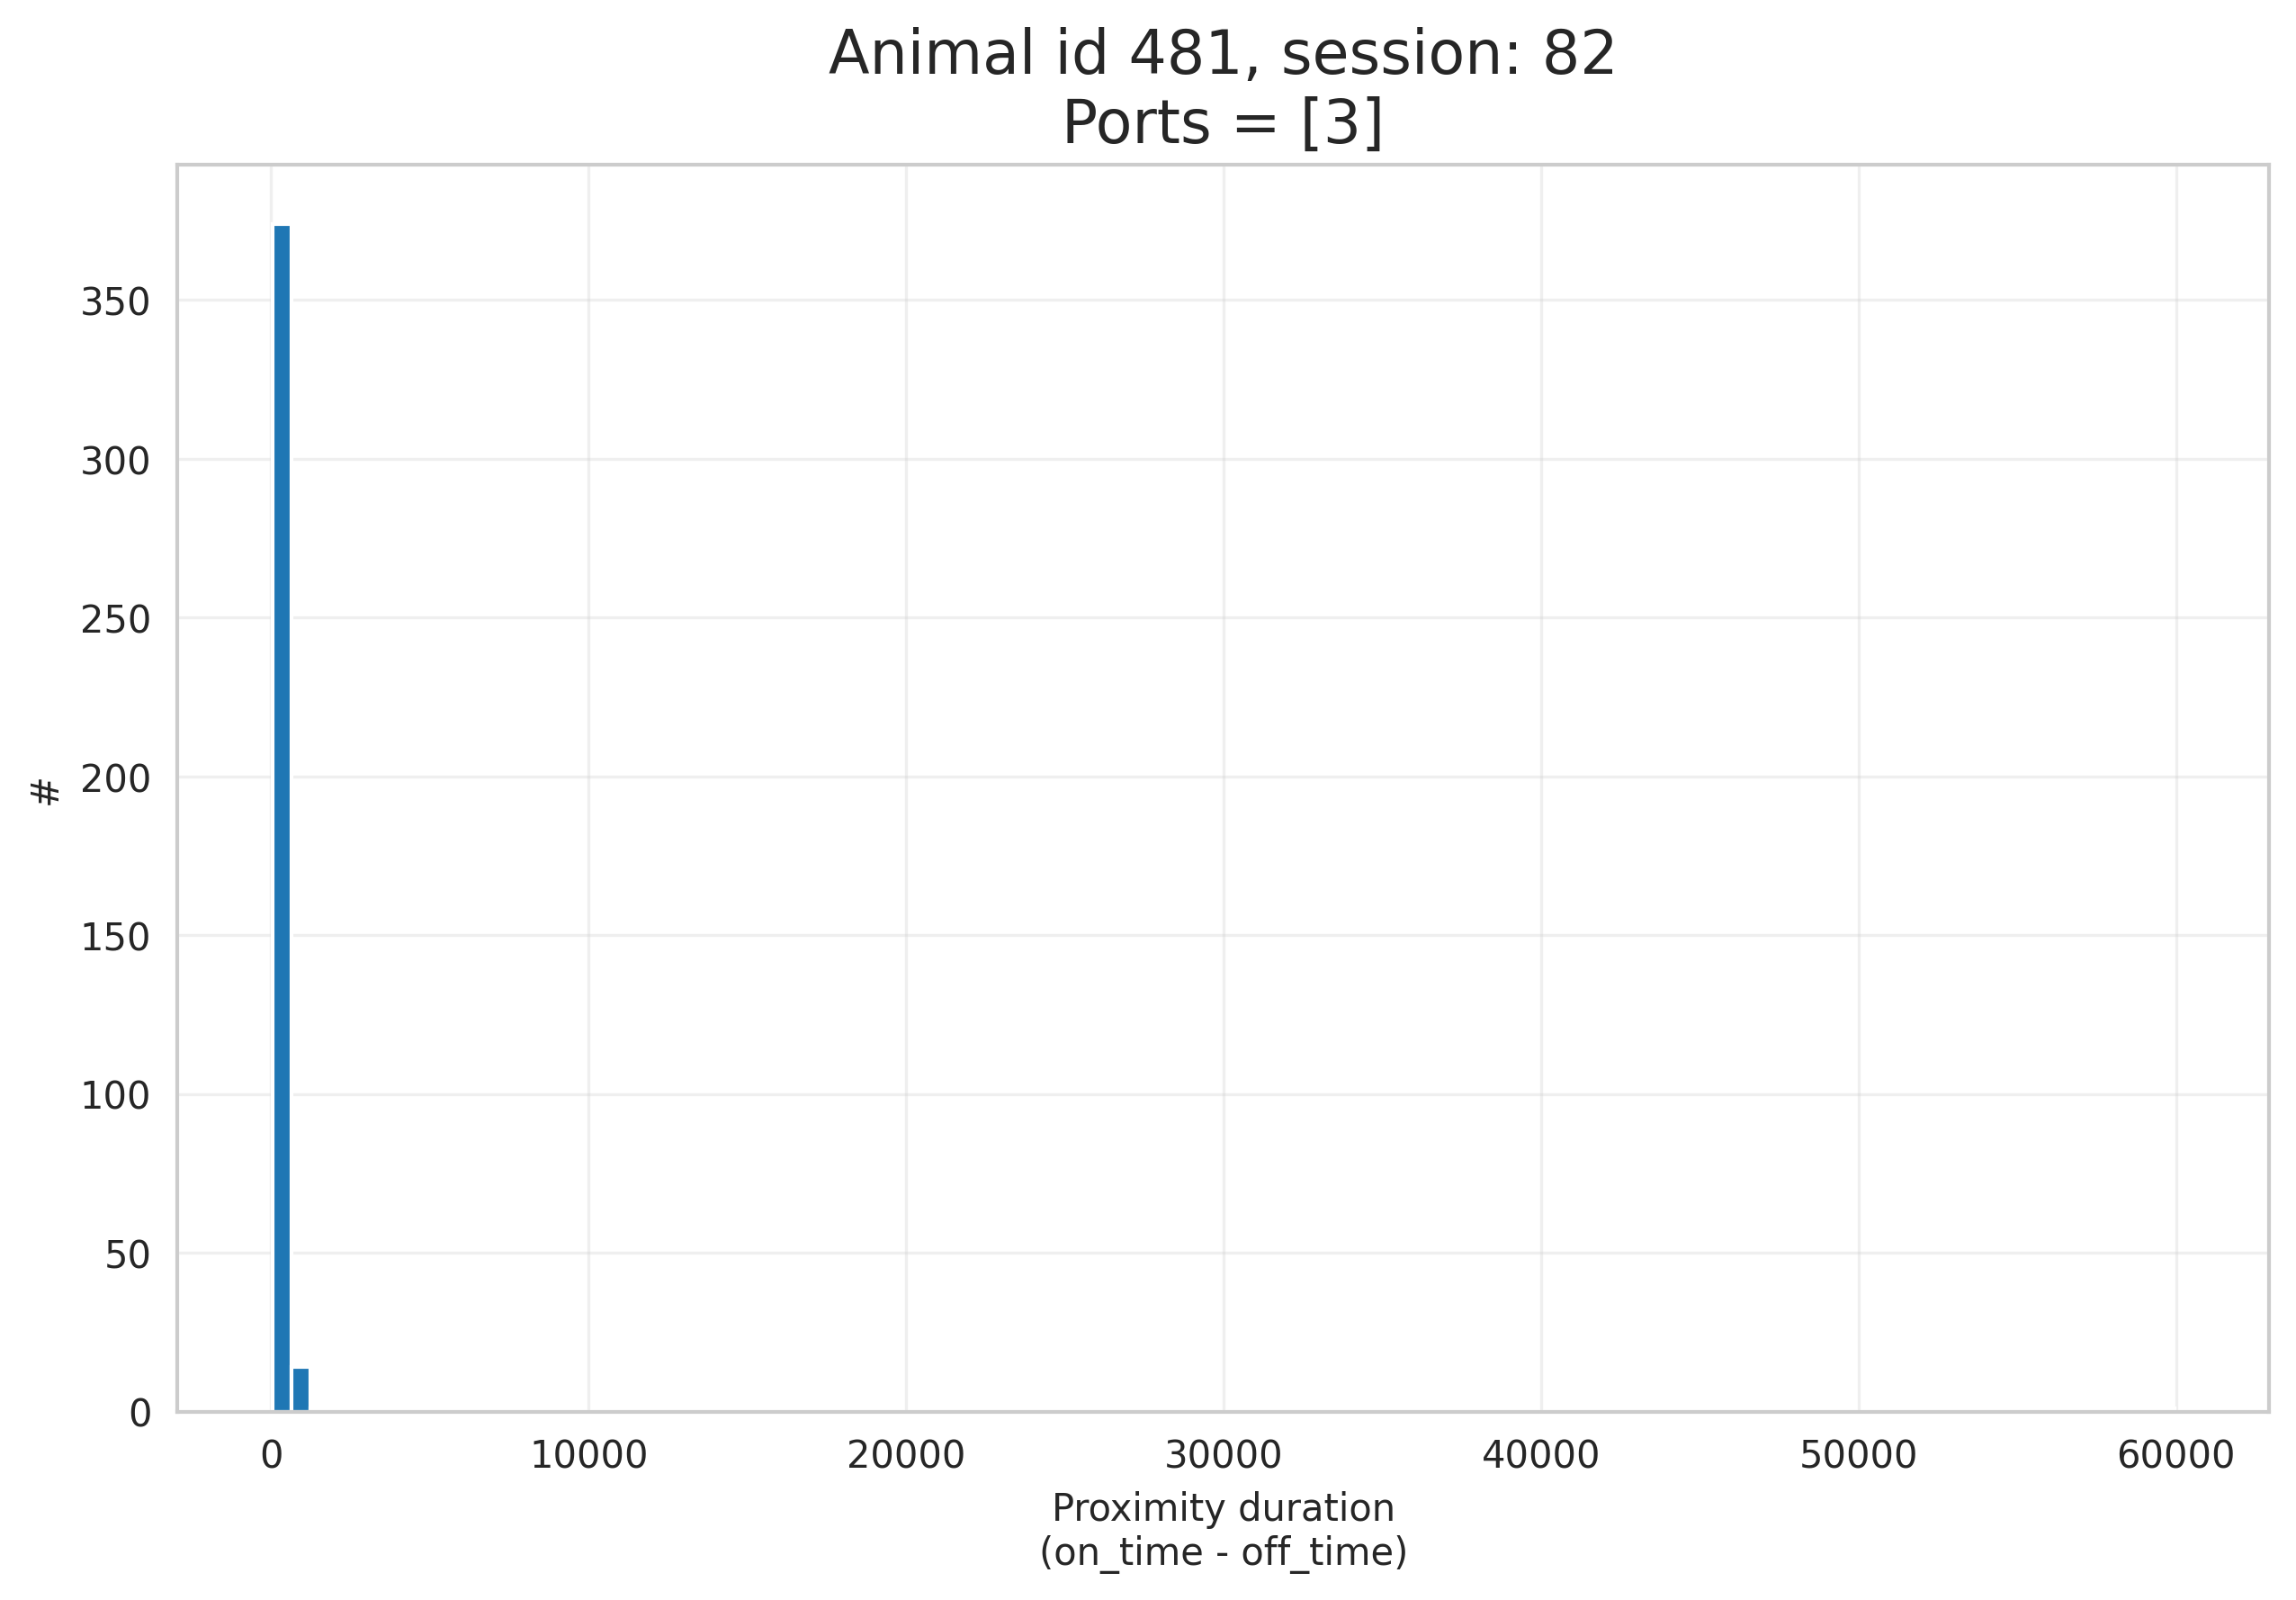

,animal_id,session,trial_idx,port,time_on,in_position,time_off,duration
605,481,82,219,3,1410090,1,1470031,59941
767,481,82,289,3,1982800,1,2020875,38075


In [224]:
# Proximity duration analysis
# plot_proximities_dur() plots histogram of proximity durations
# Parameters: animal_id (int), session (int), ports (List[int]), save_path (str)
plot_proximities_dur(animal_id, session, bins=100)

# calculate_proximity_duration() computes duration of proximity sensor activations
# Parameters: animal_id (int), session (int), ports (List)
# Returns: DataFrame with time_on, time_off, duration columns
prox_duration = calculate_proximity_duration(animal_id, session)

# Check for unusually long proximity durations (>5 seconds)
prox_duration.loc[prox_duration['duration'] > 5000]

## Plot detailed timeline for specific trials

states of Trial
   animal_id  session  trial_idx     time       state  time_spend
0        481       82        200  1284286    PreTrial       981.0
1        481       82        200  1285267       Trial       159.0
2        481       82        200  1285426       Abort       500.0
3        481       82        200  1285926  InterTrial        -0.0
Licks of Trial
Empty DataFrame
Columns: [animal_id, session, trial_idx, port, time]
Index: []
Proximities of Trial
   animal_id  session  trial_idx  port     time  in_position
0        481       82        200     3  1285210            1
1        481       82        200     3  1285385            0


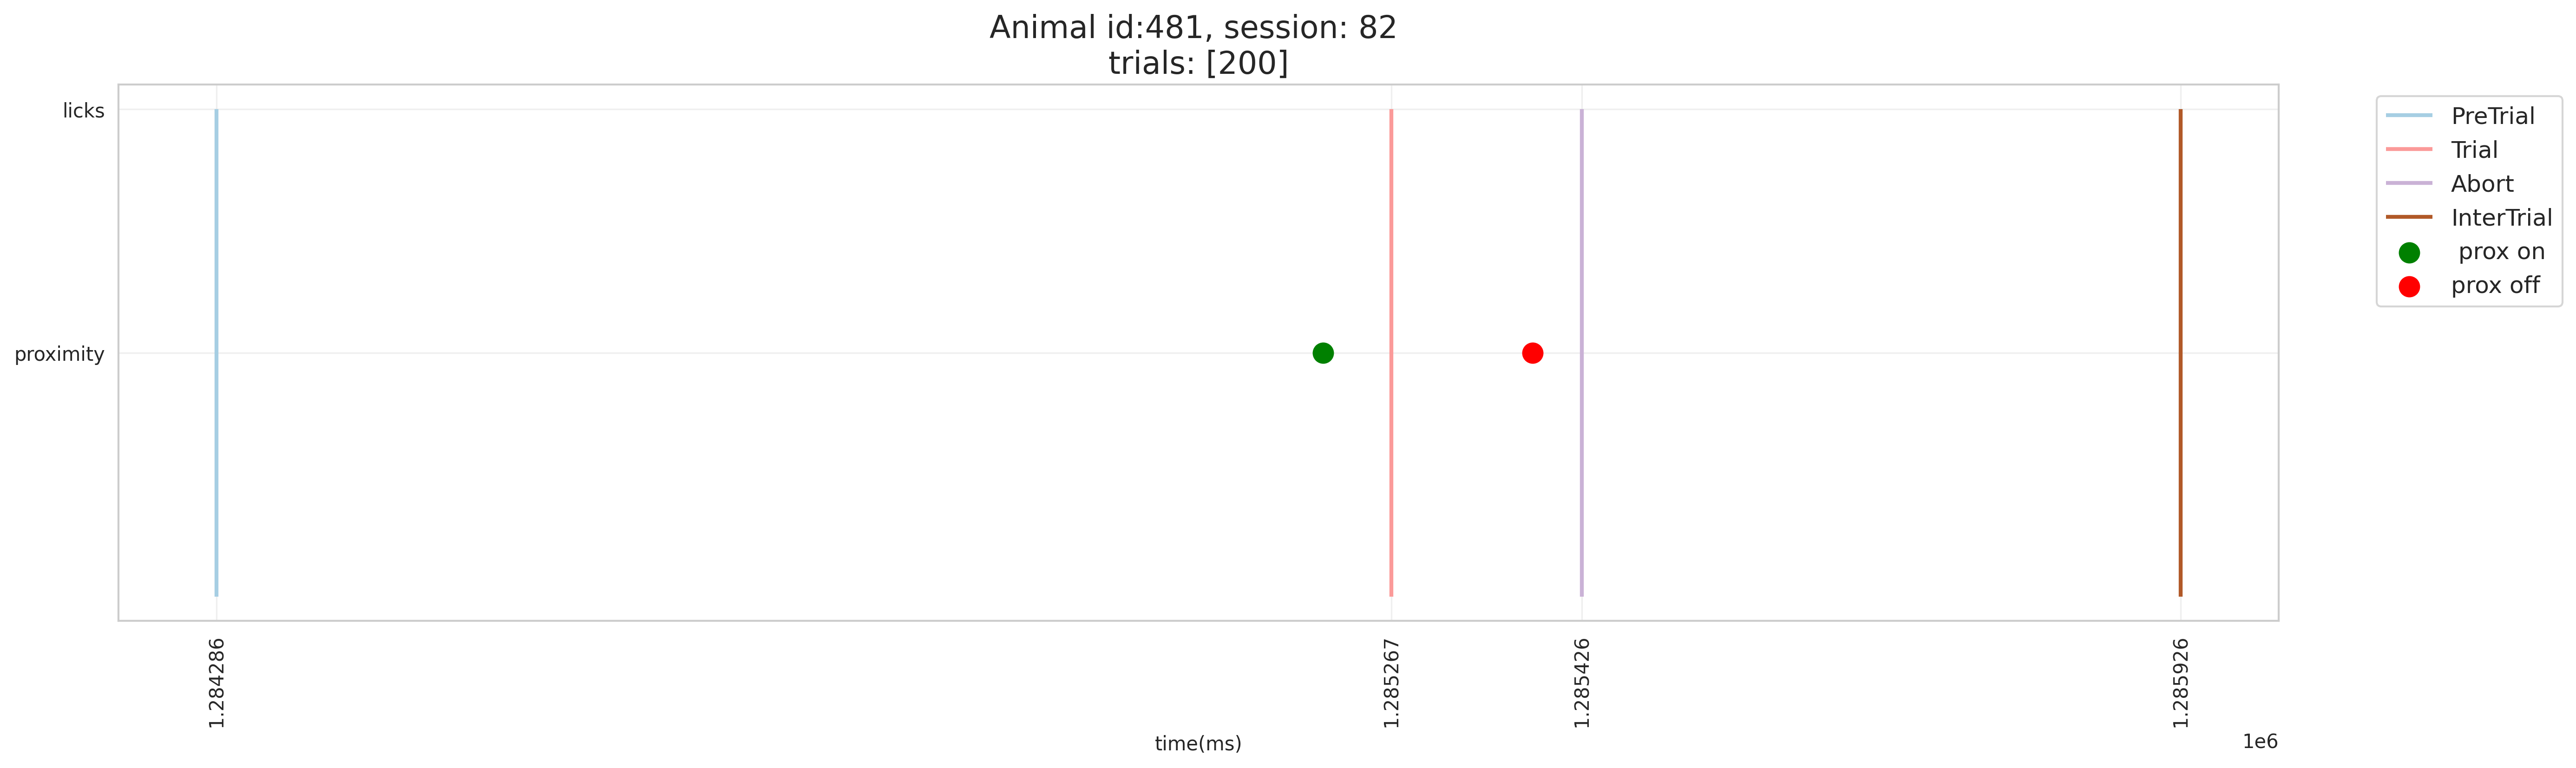

In [222]:
# Plot detailed timeline for specific trials
# plot_trial_time() creates comprehensive timeline showing states, licks, and proximity
# Parameters: animal_id (int), session (int), trials (List[int]), display_tables (bool), 
#            port (int), save_path (str)
# Returns: Tuple[DataFrame, DataFrame, DataFrame] - (trial_states, trial_licks, trial_prox)

trial_states, trial_licks, trial_prox = plot_trial_time(animal_id, session, trials=[200])

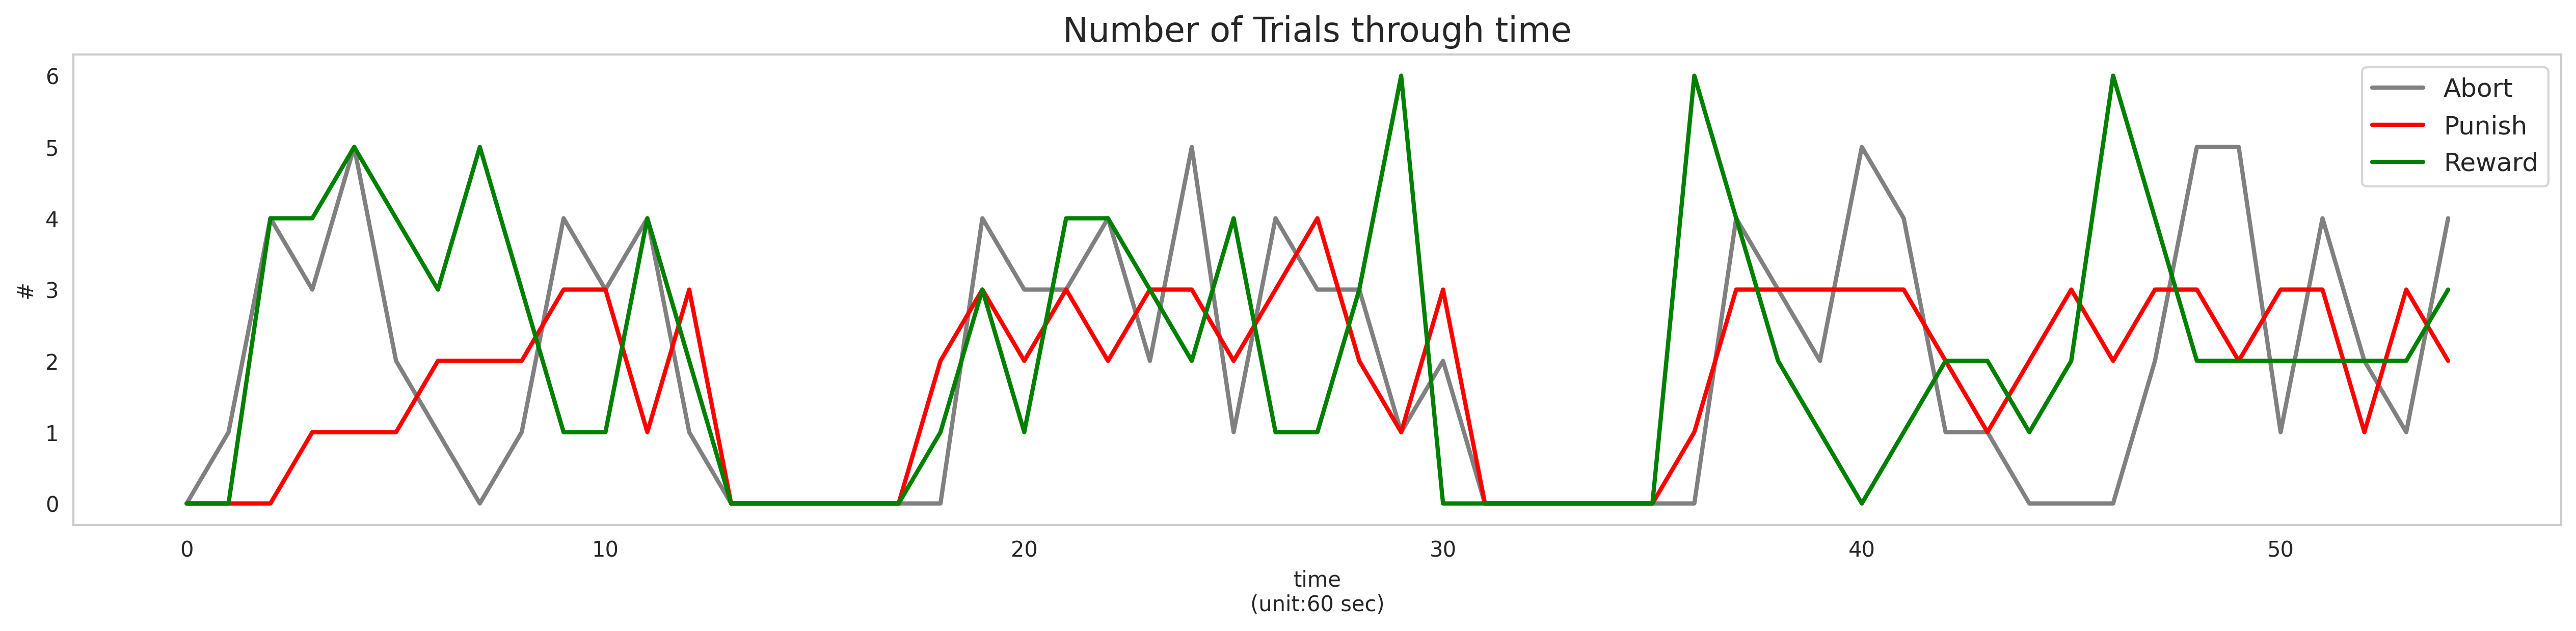

In [17]:
# Plot trial outcomes over time
# plot_states_in_time() shows distribution of trial states across session timeline
# Parameters: animal_id (int), session (int), seconds (int), save_path (str)
# Shows: Reward, Punish, Abort states binned by time

plot_states_in_time(animal_id, session, seconds=60)

## State Windows & Lick Analysis

Functions for bounding events to specific trial states.

In [59]:
# get_state_windows() returns start/end times for each state per trial.
# state_end is the onset of the next state (NaN for the last state of each trial).
# Parameters: animal_id (int), session (int), states (List[str], optional)
state_windows = get_state_windows(animal_id, session)
print(f"Total state rows: {len(state_windows)}")
state_windows.head(12)

Total state rows: 301


,animal_id,session,trial_idx,state,state_start,state_end
0,485,2,1,Trial,3007,3834.0
1,485,2,1,Reward,3834,3852.0
2,485,2,1,InterTrial,3852,6379.0
3,485,2,2,Trial,6379,6696.0
4,485,2,2,Reward,6696,6713.0
5,485,2,2,InterTrial,6713,8095.0
6,485,2,3,Trial,8095,8927.0
7,485,2,3,Reward,8927,8943.0
8,485,2,3,InterTrial,8943,9544.0
9,485,2,4,Trial,9544,12489.0


In [60]:
# get_licks_per_state() assigns each lick to the state active at that moment.
# Uses merge_asof to do an efficient range join between licks and state windows.
# Parameters: animal_id (int), session (int), states (List[str], optional)
licks_per_state = get_licks_per_state(animal_id, session)
print(f"Total licks: {len(licks_per_state)}")
print(f"Licks per state:\n{licks_per_state['state'].value_counts()}")
licks_per_state.head(10)

Total licks: 747
Licks per state:
state
InterTrial    508
Offtime       139
Trial         100
Name: count, dtype: int64


,trial_idx,lick_time,port,animal_id,session,state,state_start,state_end
0,1,3814,1,485,2,Trial,3007,3834.0
1,1,3920,1,485,2,InterTrial,3852,6379.0
2,1,4034,1,485,2,InterTrial,3852,6379.0
3,1,4132,1,485,2,InterTrial,3852,6379.0
4,1,4233,1,485,2,InterTrial,3852,6379.0
5,1,4331,1,485,2,InterTrial,3852,6379.0
6,1,4433,1,485,2,InterTrial,3852,6379.0
7,1,4563,1,485,2,InterTrial,3852,6379.0
8,1,4655,1,485,2,InterTrial,3852,6379.0
9,1,4751,1,485,2,InterTrial,3852,6379.0


In [61]:
# Filter to licks during a specific state only
trial_licks = get_licks_per_state(animal_id, session, states=["Trial"])
print(f"Licks during Trial state: {len(trial_licks)}")
trial_licks.head(10)

Licks during Trial state: 100


,trial_idx,lick_time,port,animal_id,session,state,state_start,state_end
0,1,3814,1,485,2,Trial,3007,3834.0
1,2,6679,2,485,2,Trial,6379,6696.0
2,3,8901,2,485,2,Trial,8095,8927.0
3,4,12452,2,485,2,Trial,9544,12489.0
4,5,15827,2,485,2,Trial,14803,15847.0
5,6,16621,2,485,2,Trial,16466,16641.0
6,7,17546,2,485,2,Trial,17436,17567.0
7,8,19985,2,485,2,Trial,18348,20009.0
8,9,20559,2,485,2,Trial,20546,20588.0
9,10,22429,2,485,2,Trial,22276,22450.0


Trials with a lick after Trial onset: 100


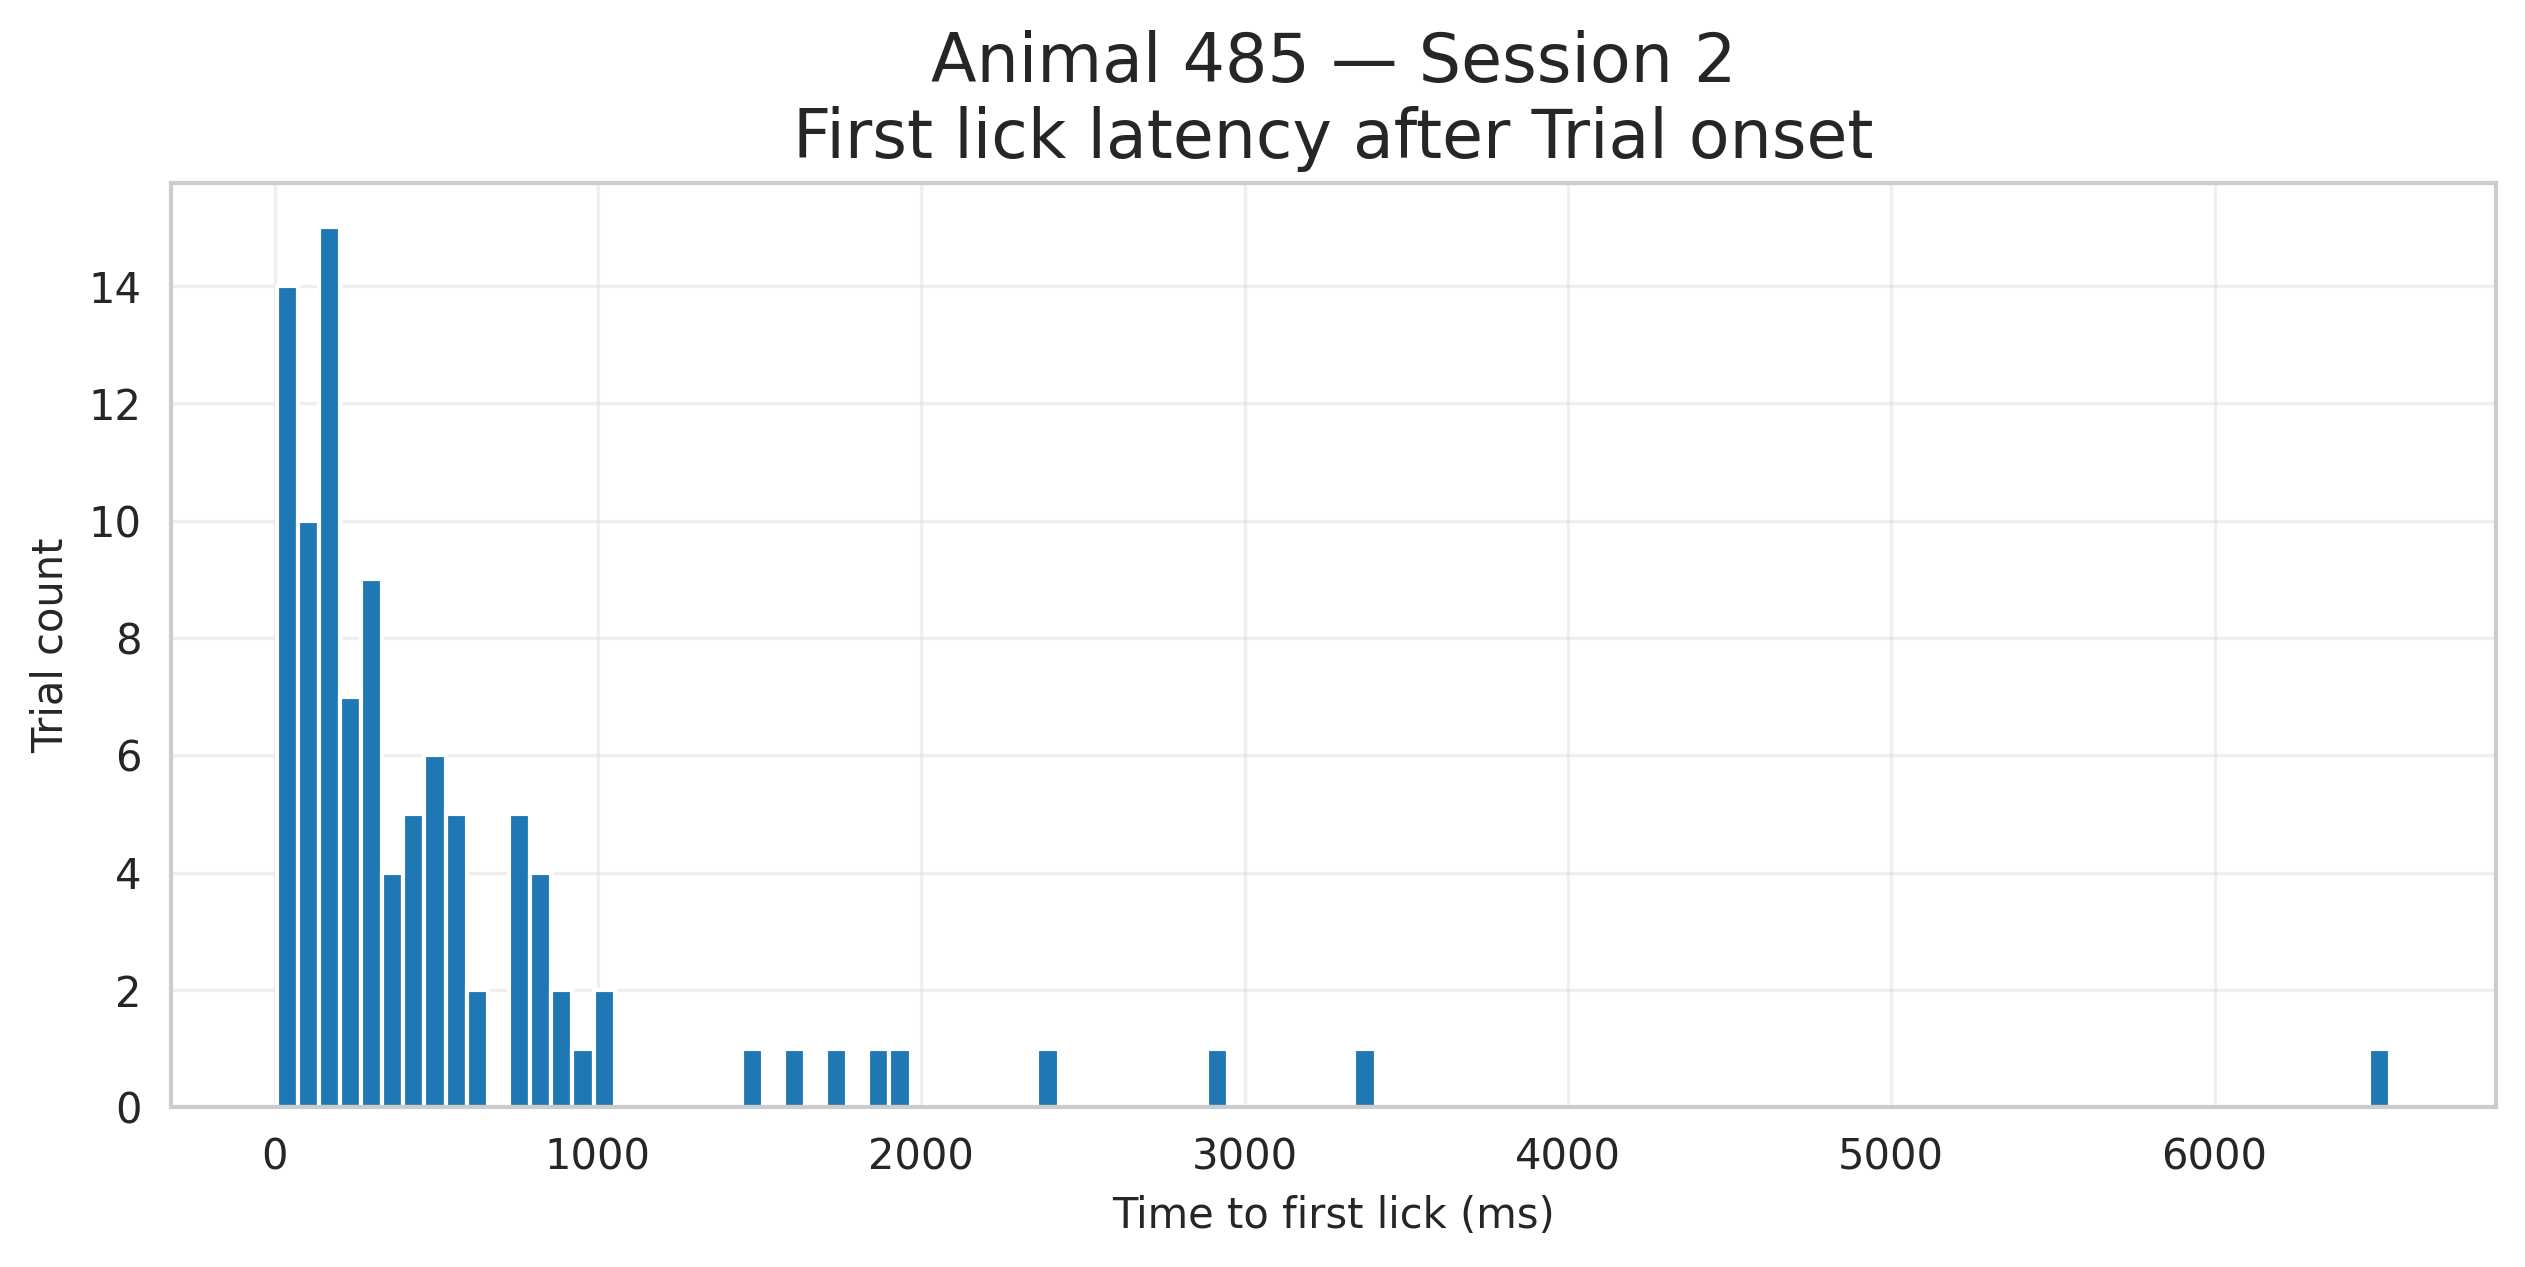

,animal_id,session,trial_idx,port,ltime,time,state,time_to_lick
0,485,2,1,1,3814,3007,Trial,807
1,485,2,2,2,6679,6379,Trial,300
2,485,2,3,2,8901,8095,Trial,806
3,485,2,4,2,12452,9544,Trial,2908
4,485,2,5,2,15827,14803,Trial,1024


In [62]:
# get_first_lick_after_state() returns the first lick per trial after a given state onset.
# Includes time_to_lick = lick_time - state_onset (ms).
# Parameters: animal_id (int), session (int), state (str), sub_state (str, optional)
f_lick = get_first_lick_after_state(animal_id, session, state="Trial")
print(f"Trials with a lick after Trial onset: {len(f_lick)}")

plt.figure(figsize=(10, 4))
plt.hist(f_lick["time_to_lick"], bins=100)
plt.xlabel("Time to first lick (ms)")
plt.ylabel("Trial count")
plt.title(f"Animal {animal_id} — Session {session}\nFirst lick latency after Trial onset")
plt.show()

f_lick.head()

## Proximity Analysis

Functions for analysing when the animal enters and leaves proximity sensors.

In [63]:
# get_first_port_exit_after_state() returns the first time the animal leaves a proximity
# sensor after a state onset — one row per trial.
# Parameters: animal_id (int), session (int), state (str), port (int, optional)
first_off = get_first_port_exit_after_state(animal_id, session, state="Trial", port=3)
print(f"Trials with port exit event: {len(first_off)}")
first_off.head(10)

Trials with port exit event: 1


,trial_idx,state,state_onset,off_position,port
0,100,Trial,207531,235042,3


Trials with both port exit and lick: 920


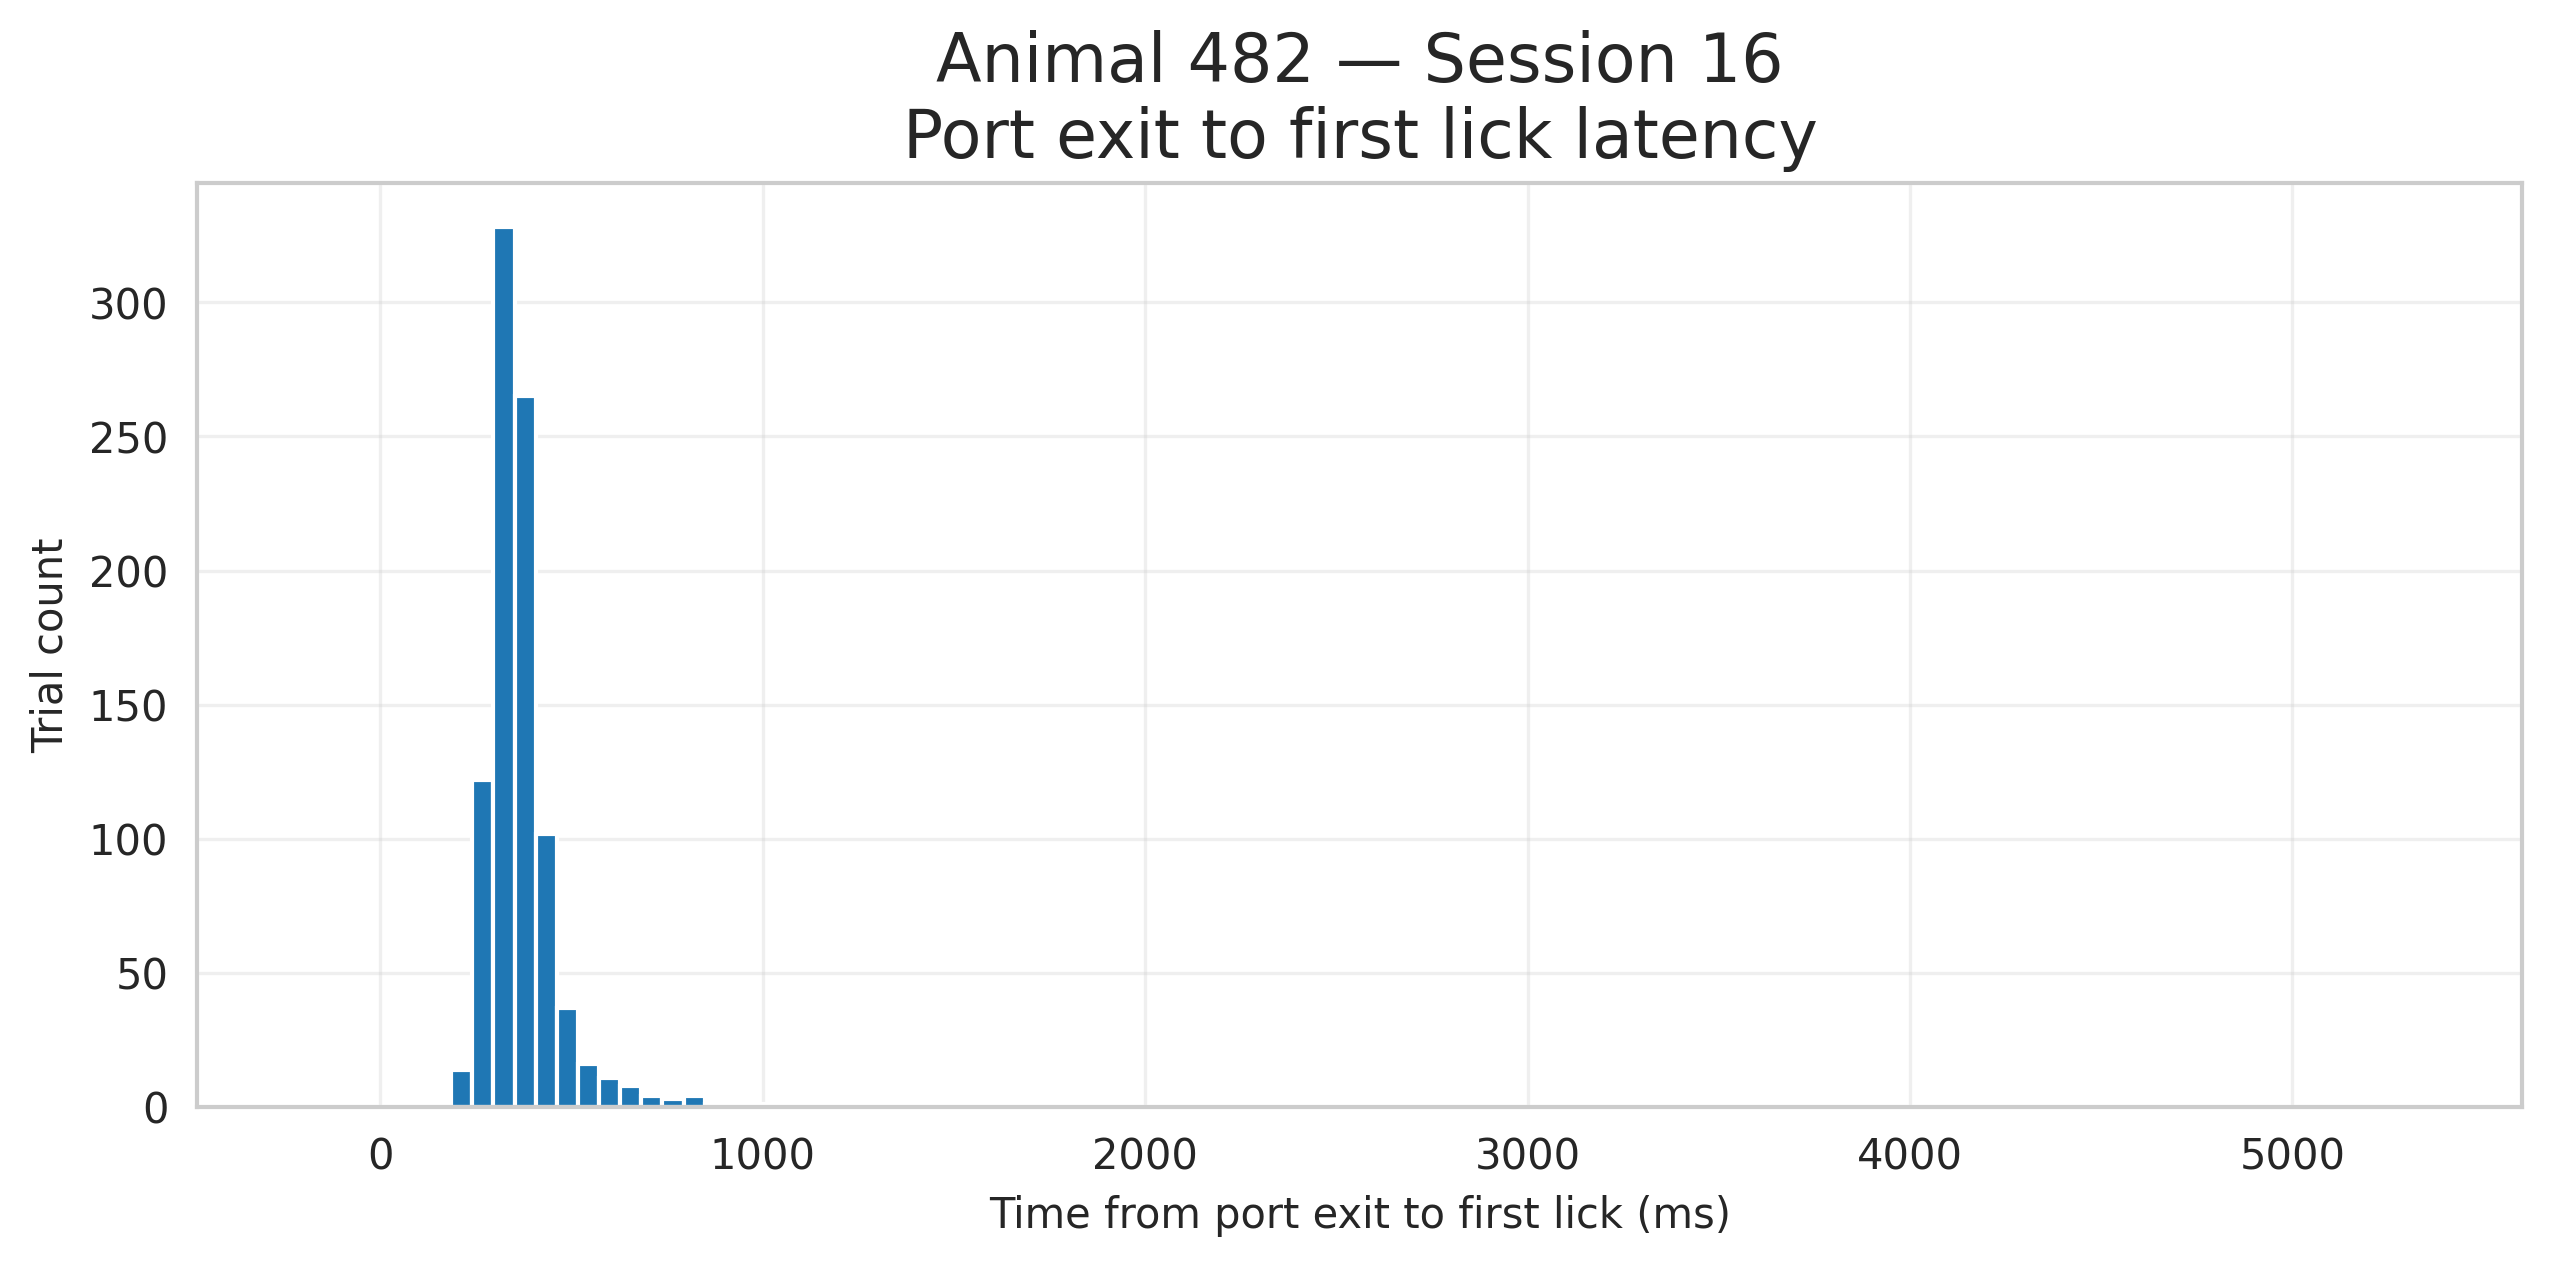

,trial_idx,state,state_onset,off_position,off_port,lick,lick_port,off_to_lick
0,1,Trial,100154,100370,3,105695,2,5325
1,2,Trial,108143,108412,3,109171,2,759
2,3,Trial,124042,124378,3,124708,1,330
3,4,Trial,132902,133157,3,133630,1,473
4,5,Trial,154528,154846,3,155050,2,204


In [109]:
# get_port_exit_to_lick_latency() measures how long it takes the animal to lick after
# leaving the center port — combining get_first_port_exit_after_state and get_first_lick_after_state.
# Parameters: animal_id (int), session (int), state (str), port (int)
off_to_lick = get_port_exit_to_lick_latency(animal_id, session, state="Trial", port=3)
print(f"Trials with both port exit and lick: {len(off_to_lick)}")

plt.figure(figsize=(10, 4))
plt.hist(off_to_lick["off_to_lick"], bins=100)
plt.xlabel("Time from port exit to first lick (ms)")
plt.ylabel("Trial count")
plt.title(f"Animal {animal_id} — Session {session}\nPort exit to first lick latency")
plt.show()

off_to_lick.head()

In [86]:
# get_licks_during_proximity() is a QC check: detects licks that occurred while the
# animal was inside a proximity sensor (ON period). has_lick=True flags anomalies.
# Parameters: animal_id (int), session (int), port (int, optional)
report = get_licks_during_proximity(animal_id, session)
print(f"Total ON-OFF windows : {len(report)}")
print(f"Windows with licks   : {report['has_lick'].sum()}")
report[report["has_lick"]]

KeyError: 'port'

542 ON-OFF pairs across all trials


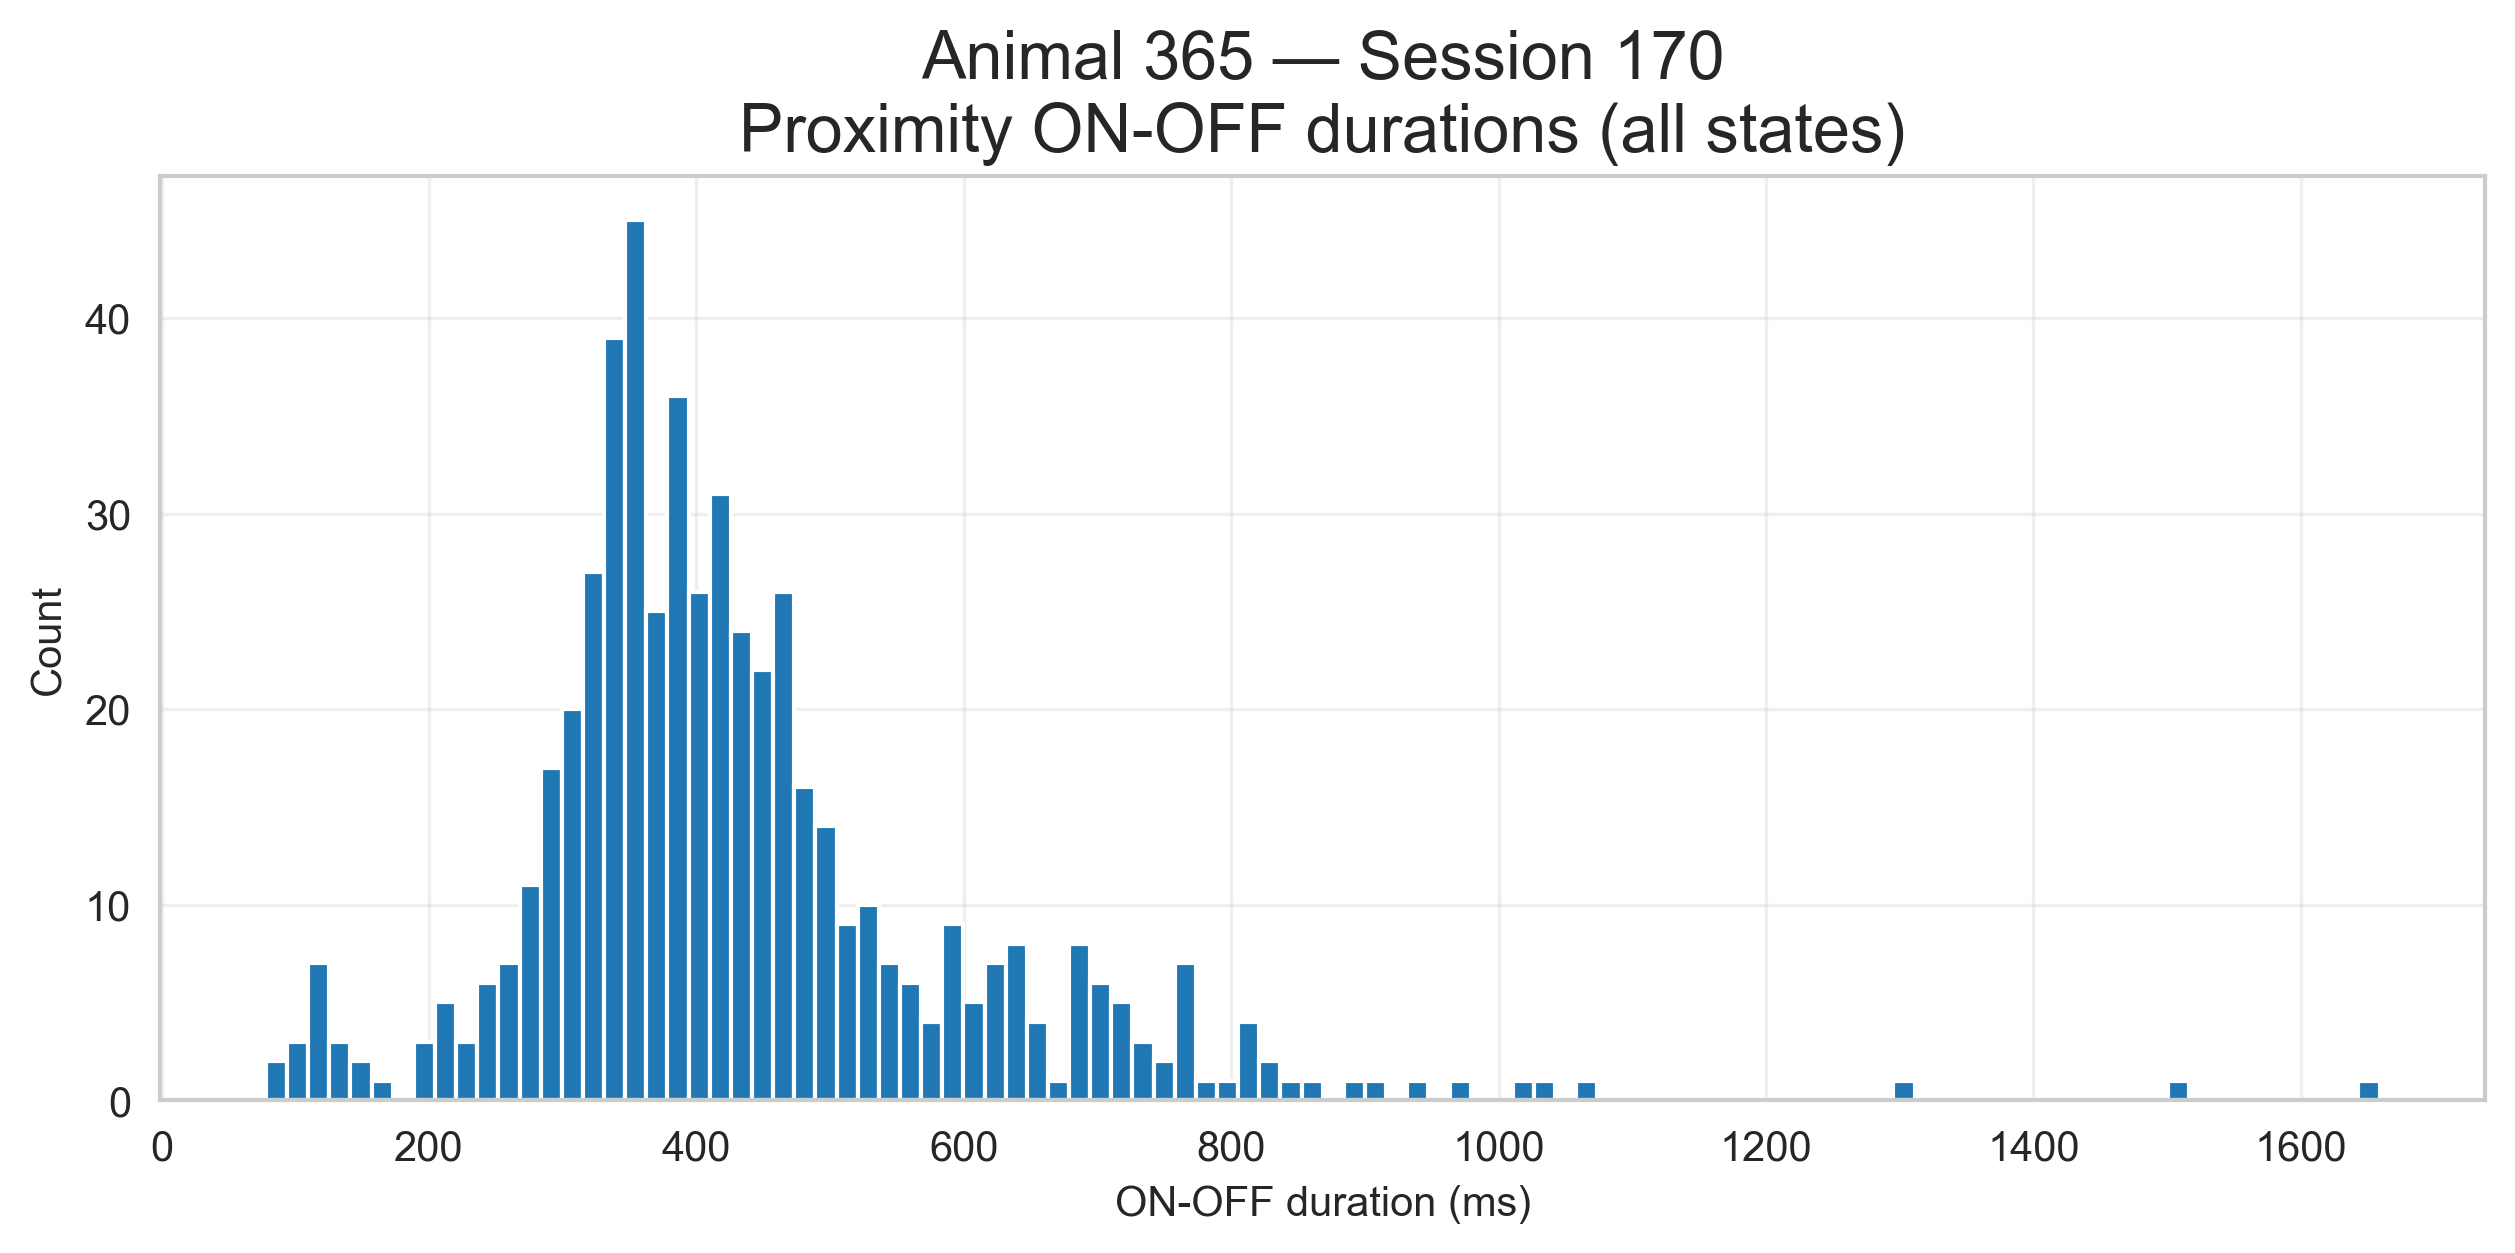

,trial_idx,time_on,time_off,duration,state
0,1,98837.0,98950.0,113.0,PreTrial
1,2,107160.0,107401.0,241.0,PreTrial
2,3,109138.0,109491.0,353.0,PreTrial
3,4,118604.0,118820.0,216.0,PreTrial
4,5,119804.0,120103.0,299.0,unknown
5,6,121808.0,122156.0,348.0,PreTrial
6,7,133797.0,134101.0,304.0,PreTrial
7,8,135008.0,135323.0,315.0,unknown
8,9,136935.0,137300.0,365.0,unknown
9,10,138291.0,138618.0,327.0,unknown


In [17]:
# get_trial_proximity_timings() returns every ON-OFF proximity pair across all trials,
# with the state active at time_on labelled for each pair.
# Parameters: animal_id (int), session (int), port (int, default 3)
timings = get_trial_proximity_timings(animal_id, session)
print(f"{len(timings)} ON-OFF pairs across all trials")

plt.figure(figsize=(10, 4))
plt.hist(timings["duration"], bins=100)
plt.xlabel("ON-OFF duration (ms)")
plt.ylabel("Count")
plt.title(f"Animal {animal_id} — Session {session}\nProximity ON-OFF durations (all states)")
plt.show()

timings.head(10)

In [18]:
# find_consecutive_runs() returns rows that belong to sustained runs (length > 1)
# in a binary column — useful for finding prolonged in/out-of-position periods.
# Parameters: df (pd.DataFrame), col (str, default "in_position")
from ethopy_analysis.data.loaders import get_trial_proximities

proximities = get_trial_proximities(animal_id, session)
sustained = find_consecutive_runs(proximities, col="in_position")
print(f"Rows in runs > 1: {len(sustained)}")
sustained.head()

Rows in runs > 1: 2


,animal_id,session,trial_idx,port,time,in_position
225,365,170,62,3,436354,0
226,365,170,62,3,436355,0


In [88]:
# add_column_by_key() maps column(s) from one DataFrame onto another by a shared key.
# Useful for enriching lick or proximity data with trial-level information.
# Parameters: df_main, df_source, key_col (str), value_col (str or List[str]), fill_value

from ethopy_analysis.data.loaders import get_trial_states, get_trial_licks

trial_states = get_trial_states(animal_id, session)
# Keep one row per trial: the outcome state (Reward / Punish / Abort)
outcomes = (
    trial_states[trial_states["state"].isin(["Reward", "Punish", "Abort"])]
    .drop_duplicates(subset="trial_idx")[["trial_idx", "state"]]
    .rename(columns={"state": "outcome"})
)

licks = get_trial_licks(animal_id, session)
licks_with_outcome = add_column_by_key(licks, outcomes, key_col="trial_idx", value_col="outcome")
print(licks_with_outcome["outcome"].value_counts())
licks_with_outcome.head()

Series([], Name: outcome, dtype: int64)


,animal_id,session,trial_idx,port,time,outcome


## Raster Plot: ON-OFF Proximity & State Timing

`get_session_proximity_data()` builds a rich per-trial DataFrame.  
`on_off_sess_states()` plots it as a raster with flexible alignment and sorting.

In [89]:
# get_session_proximity_data() builds a per-trial DataFrame containing:
#   - scalar columns: main_on_time, main_off_time, main_on_off_dur,
#                     response_lick_time, reaction_time, outcome, state_times
#   - list columns:   all_on_off_pairs, all_lick_times  (for full raster plotting)
# Parameters: animal_id (int), session (int), trials (List[int], optional),
#             main_state (str, default "Trial"), port (int, default 3)

session_df = get_session_proximity_data(animal_id, session, trials=range(1, 101))
print(f"Trials loaded: {len(session_df)}")
session_df[["trial_idx", "outcome", "main_on_time", "main_off_time",
            "main_on_off_dur", "response_lick_time", "reaction_time"]].head(10)

KeyError: 'time'

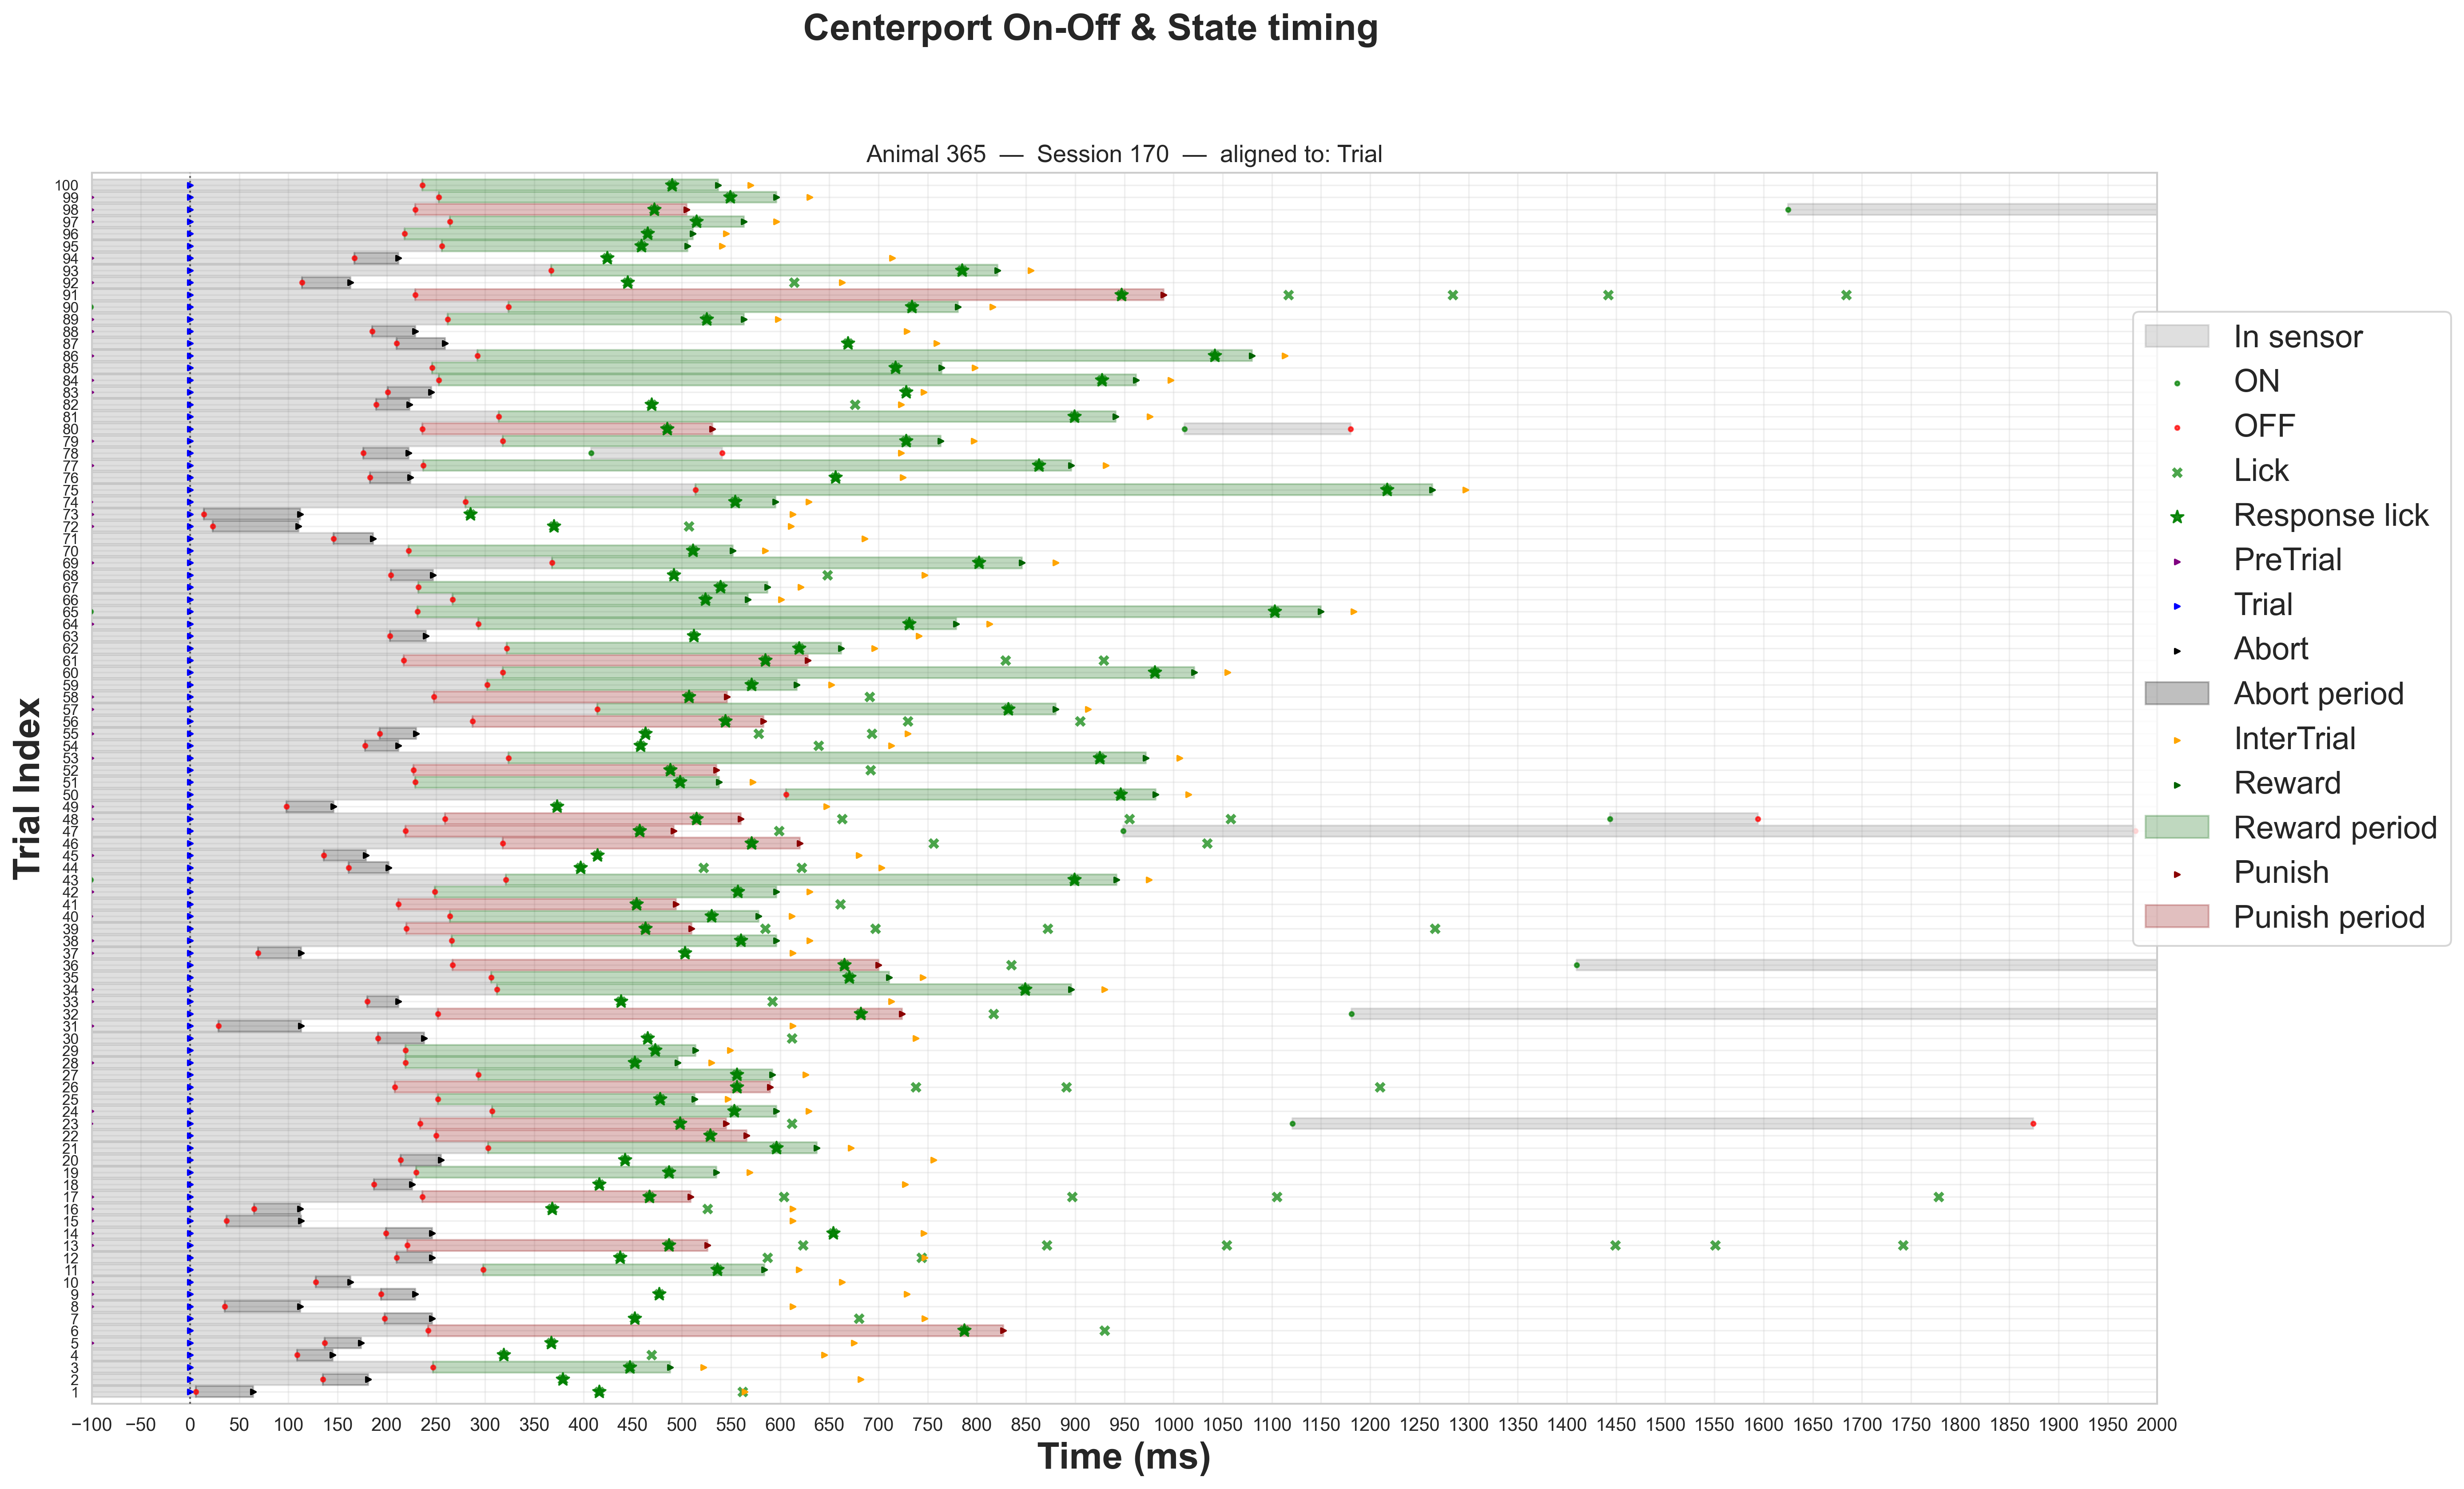

In [21]:
# plot_trial_events_raster() plots the raster. Align to the main ON event (default).
# Parameters: session_df, animal_id, session, align_to, sort_by, xlim, figsize, state_color
# Returns: (fig, ax)
fig, ax = plot_trial_events_raster(
    session_df,
    animal_id=animal_id,
    session=session,
)

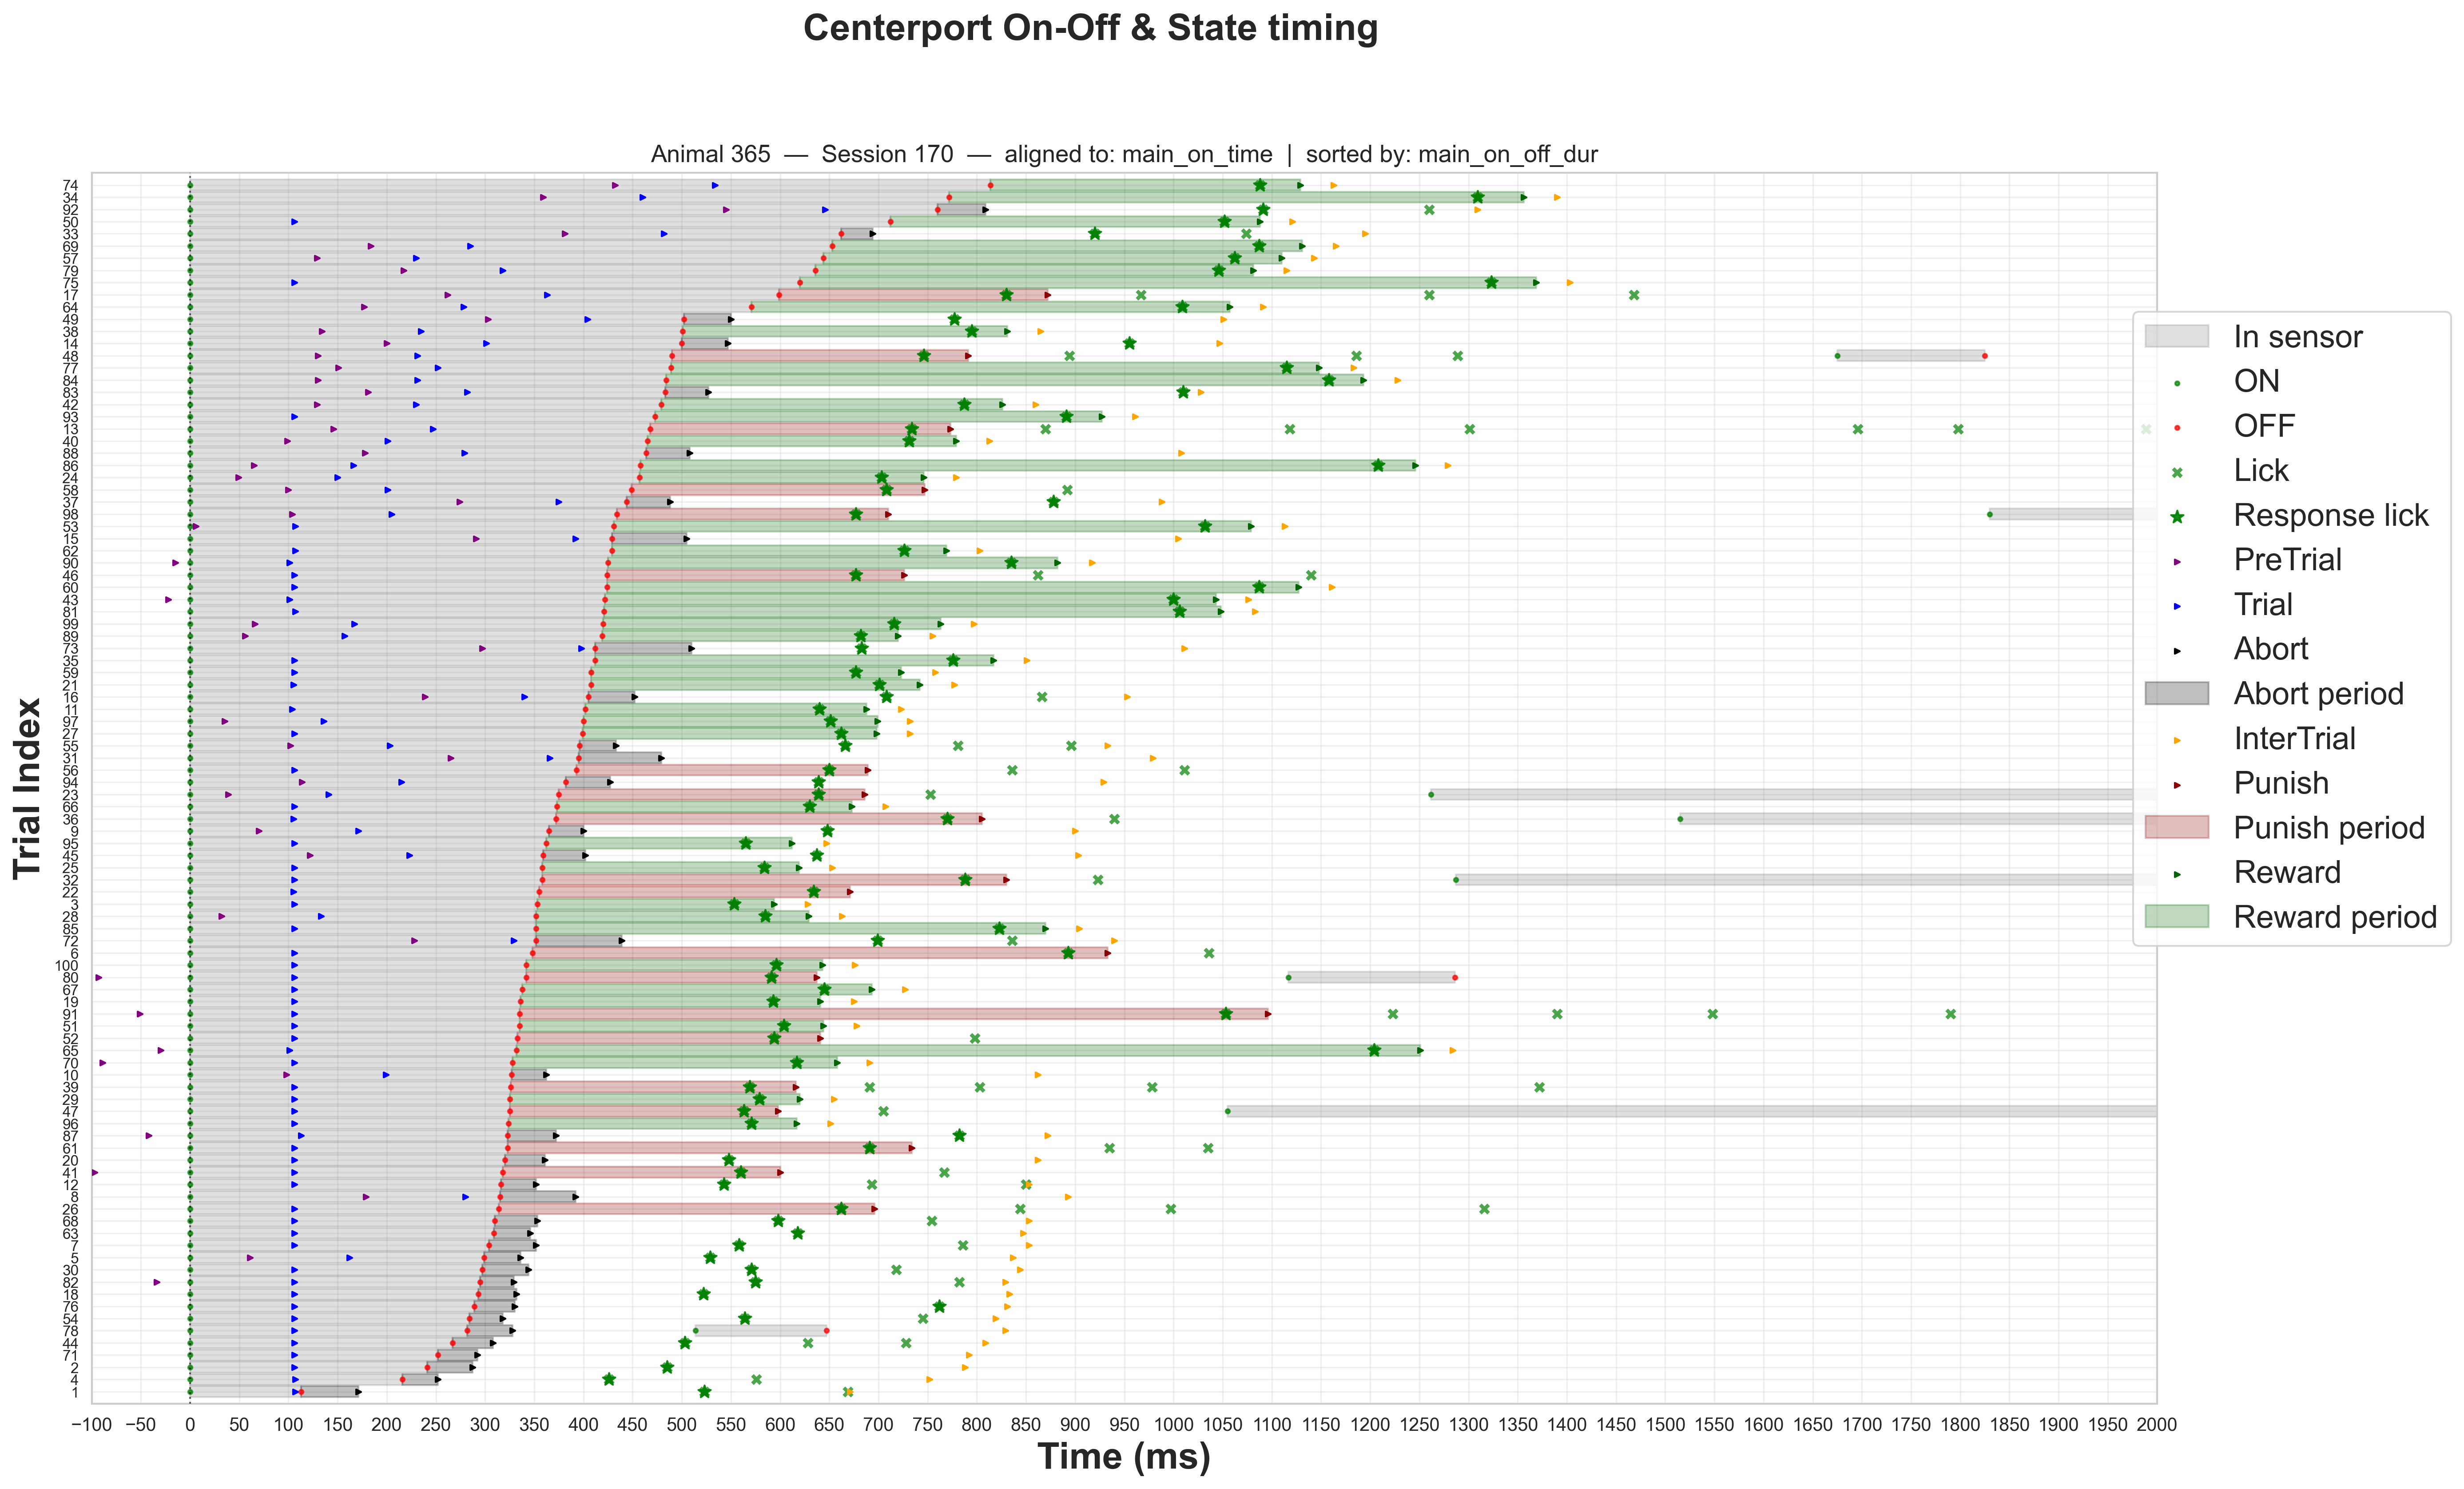

In [24]:
# Align to Trial state onset, sort by time spent in center port
fig, ax = plot_trial_events_raster(
    session_df,
    animal_id=animal_id,
    session=session,
    align_to="main_on_time",
    sort_by="main_on_off_dur",
)

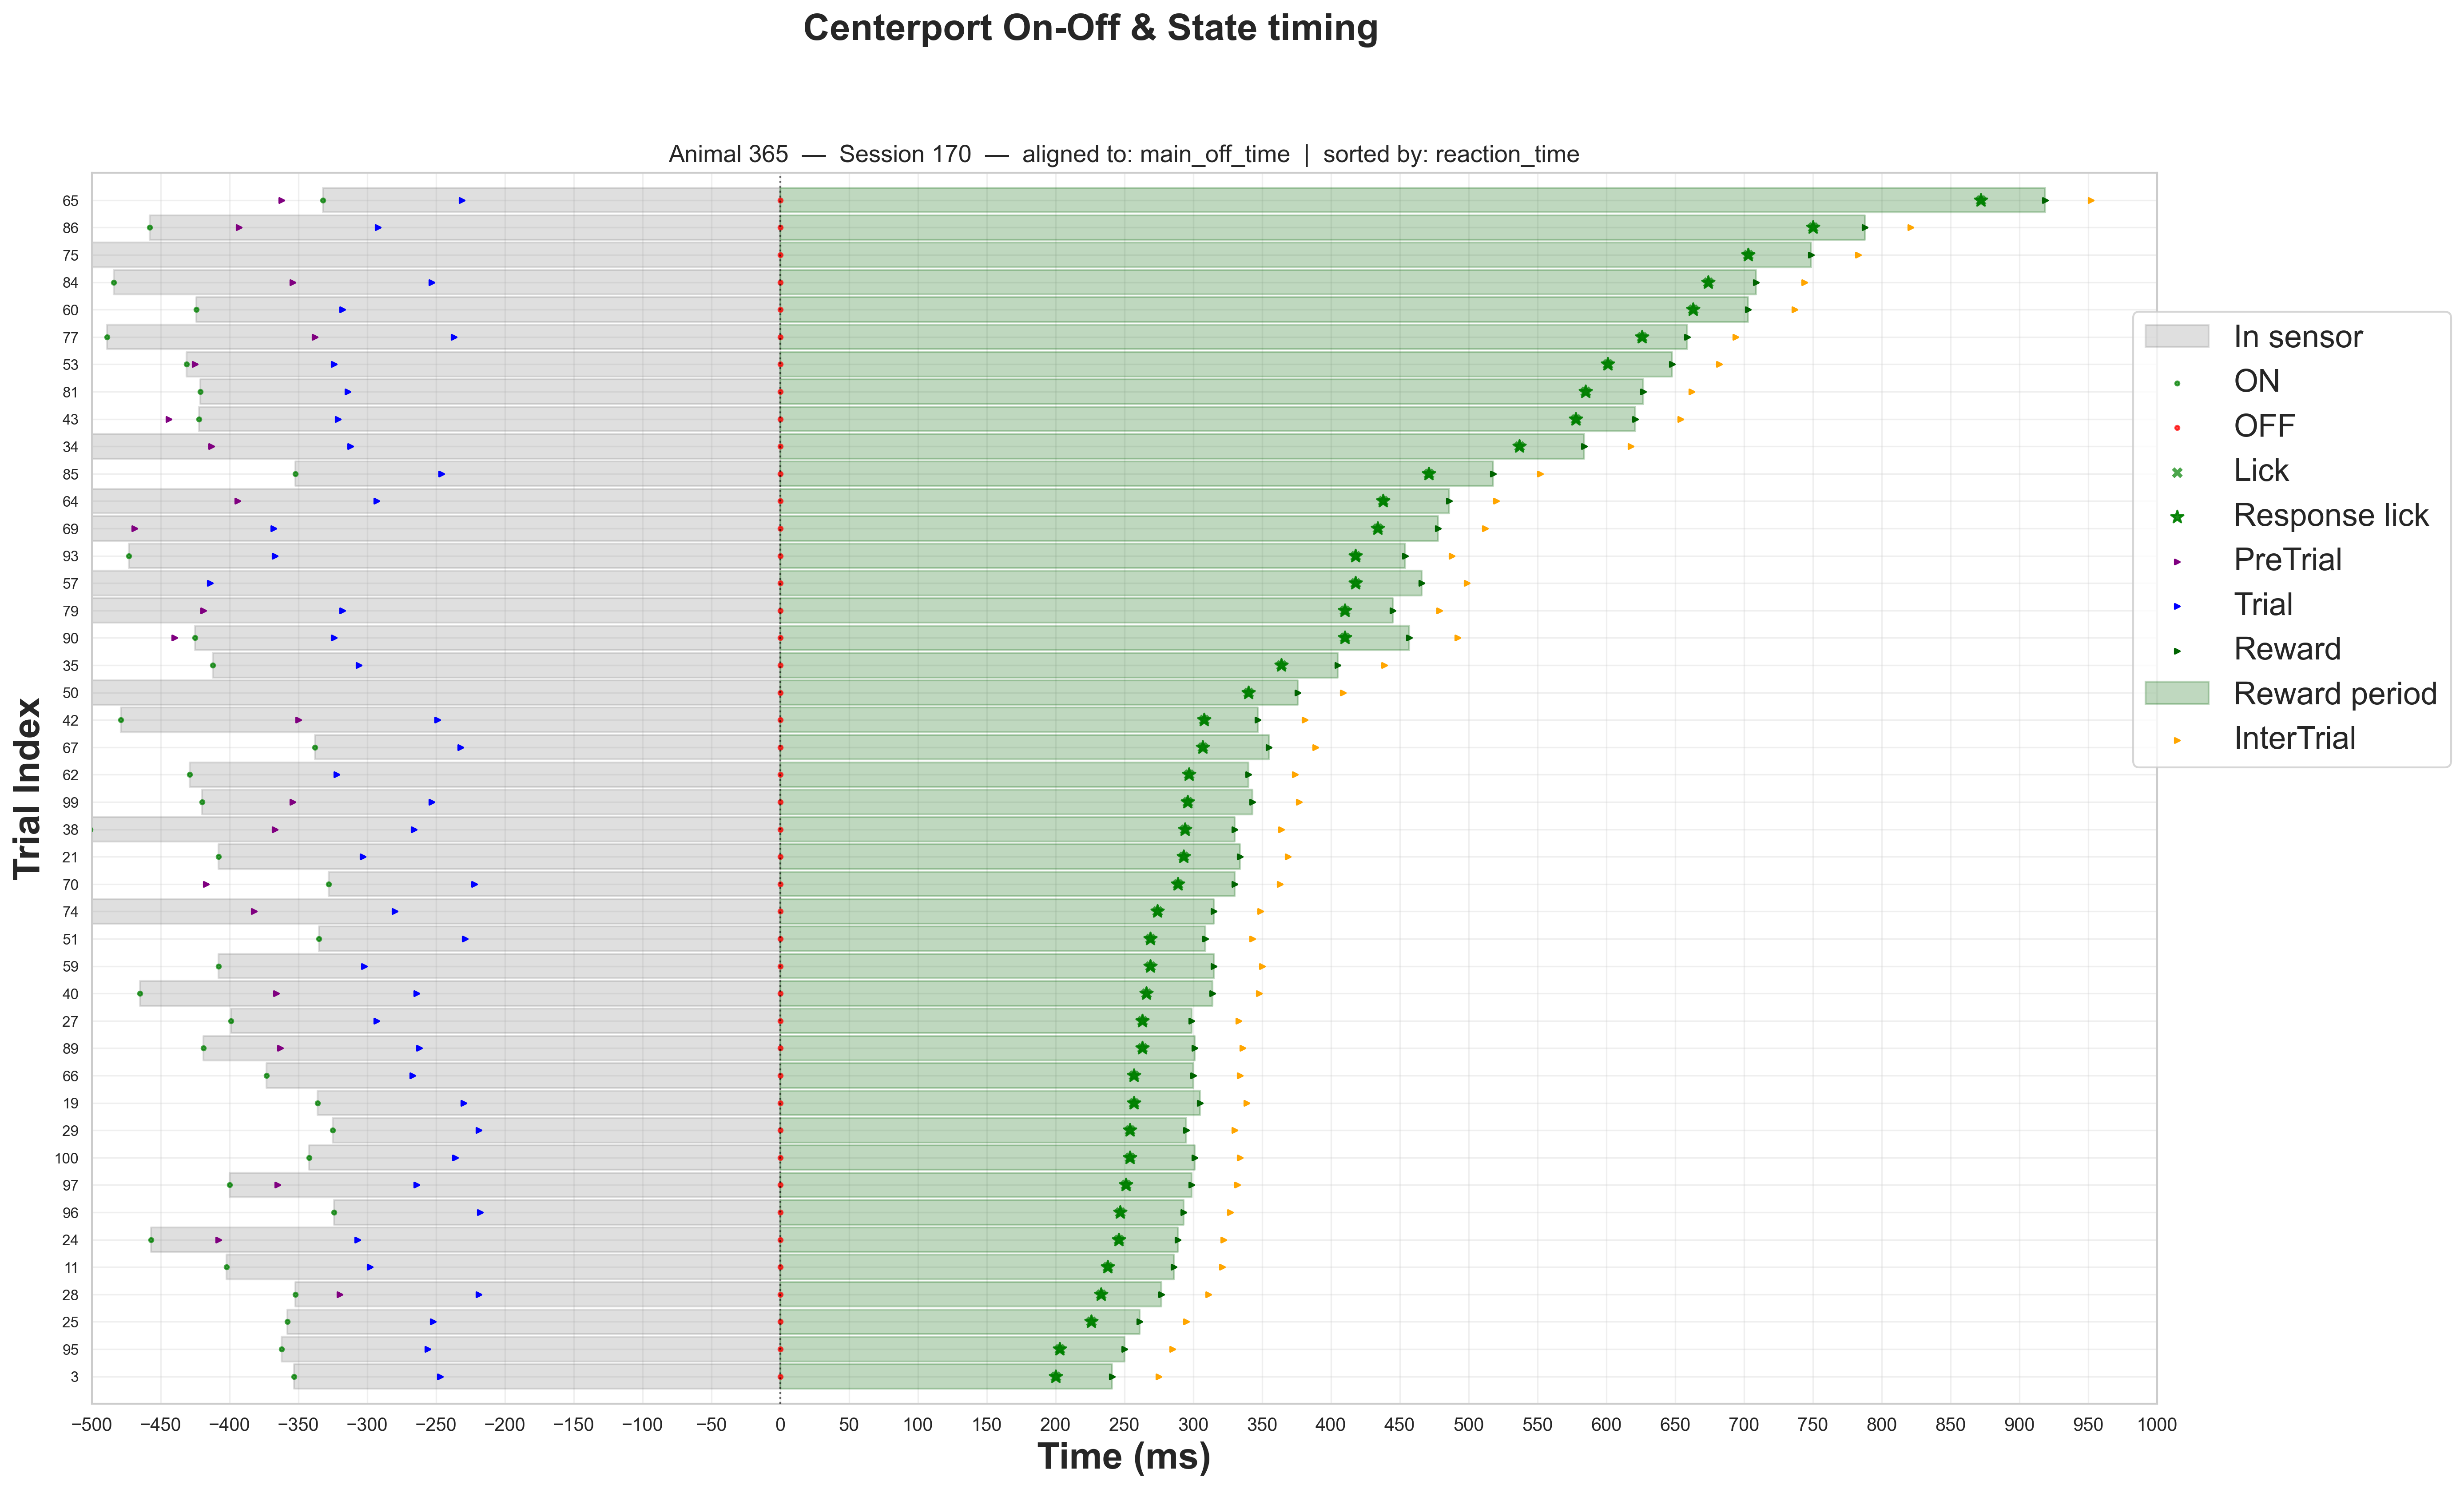

In [23]:
# Align to main OFF (decision point), sort by reaction time — rewarded trials only
fig, ax = plot_trial_events_raster(
    session_df[session_df["outcome"] == "Reward"],
    animal_id=animal_id,
    session=session,
    align_to="main_off_time",
    sort_by="reaction_time",
    xlim=(-500, 1000),
)